# CNN Spatio-Temporal Stream — Deepfake Detection

## Two-Stream Late Fusion Architecture (Stream 2 of 2)

This notebook implements a **research-grade Spatio-Temporal CNN** using EfficientNet-B4 backbone with **BiLSTM Temporal Aggregation** for deepfake detection.

### Key Research Contributions:

1. **Temporal Modeling (BiLSTM + Multi-Head Attention)**
   - Unlike naive frame averaging, we model inter-frame dependencies
   - Detects temporal flickering, blending shifts, and motion anomalies
   - Enables detection of GAN/Diffusion artifacts that manifest across frames

2. **Grad-CAM Visualization**
   - Provides visual proof of what the model learns
   - Shows attention on facial regions (jawline, eyes, blending boundaries)
   - Essential for research paper methodology section

```
┌──────────────────────────────────────────────────────────────────────────────┐
│                    SPATIO-TEMPORAL ARCHITECTURE                              │
├──────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│   Video (T frames) ──→ MTCNN Face Detection ──→ T × (224, 224, 3) crops     │
│                                                                              │
│   ┌─────────────────────────────────────────────────────────────────────┐   │
│   │  SPATIAL FEATURE EXTRACTION                                          │   │
│   │  EfficientNet-B4 (pretrained, 1792-dim features per frame)          │   │
│   │                                                                      │   │
│   │      Frame 1 ──→ [f₁]                                               │   │
│   │      Frame 2 ──→ [f₂]     ──→ Feature Sequence (T × 1792)           │   │
│   │      ...                                                             │   │
│   │      Frame T ──→ [fₜ]                                               │   │
│   └─────────────────────────────────────────────────────────────────────┘   │
│                              ↓                                               │
│   ┌─────────────────────────────────────────────────────────────────────┐   │
│   │  TEMPORAL AGGREGATION (BiLSTM + Multi-Head Attention)               │   │
│   │                                                                      │   │
│   │  [f₁, f₂, ..., fₜ] ──→ BiLSTM (2-layer, bidirectional)              │   │
│   │                                ↓                                     │   │
│   │                    Multi-Head Self-Attention (4 heads)               │   │
│   │                                ↓                                     │   │
│   │                    Weighted Temporal Pooling                         │   │
│   │                                ↓                                     │   │
│   │                    Video-Level Representation (512-dim)              │   │
│   └─────────────────────────────────────────────────────────────────────┘   │
│                              ↓                                               │
│   ┌─────────────────────────────────────────────────────────────────────┐   │
│   │  CLASSIFIER                                                          │   │
│   │  Linear(512 → 256) → BatchNorm → GELU → Dropout                     │   │
│   │  Linear(256 → 128) → BatchNorm → GELU → Dropout                     │   │
│   │  Linear(128 → 1) → Sigmoid                                          │   │
│   │                        ↓                                             │   │
│   │                    P_CNN (0 = Real, 1 = Fake)                        │   │
│   └─────────────────────────────────────────────────────────────────────┘   │
│                                                                              │
└──────────────────────────────────────────────────────────────────────────────┘

                    ↓ LATE FUSION ↓

        P_final = w₁ × P_CNN + w₂ × P_rPPG (from Stream 1)
```

**Output:** `cnn_predictions.csv` with video-level P_CNN scores for Late Fusion

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# P100 GPU COMPATIBILITY FIX — Must run BEFORE any other imports
# ═══════════════════════════════════════════════════════════════════════════════
# PyTorch 2.6+ dropped SM 6.0 (P100) support. This cell detects the GPU
# and installs a compatible PyTorch version BEFORE torch is imported.
# ═══════════════════════════════════════════════════════════════════════════════

import subprocess, sys, os

def ensure_p100_compatible_pytorch():
    """Install P100-compatible PyTorch if needed (before any torch imports)."""
    try:
        # Detect GPU compute capability using nvidia-smi (no torch needed)
        result = subprocess.run(
            ['nvidia-smi', '--query-gpu=name,compute_cap', '--format=csv,noheader'],
            capture_output=True, text=True, timeout=10
        )
        if result.returncode != 0:
            print("No GPU detected via nvidia-smi — skipping PyTorch fix")
            return

        gpu_info = result.stdout.strip().split('\n')[0]
        print(f"GPU detected: {gpu_info}")

        # Parse compute capability
        parts = gpu_info.split(',')
        if len(parts) >= 2:
            compute_cap = parts[-1].strip()
            major = int(compute_cap.split('.')[0])
        else:
            return

        if major >= 7:
            print(f"✓ Compute capability {compute_cap} — default PyTorch is compatible")
            return

        # Pascal (SM 6.x) or older — check if current PyTorch works
        print(f"⚠️ Pascal GPU detected (SM {compute_cap}) — checking PyTorch compatibility...")

        # Test if current torch works on this GPU (in a subprocess to avoid polluting our process)
        test = subprocess.run(
            [sys.executable, '-c',
             'import torch; torch.zeros(1, device="cuda"); print("OK")'],
            capture_output=True, text=True, timeout=30
        )
        if test.stdout.strip() == "OK":
            print("✓ Current PyTorch works on P100 — no fix needed")
            return

        # Current PyTorch is incompatible — install a compatible version
        # Get current version for logging
        ver_result = subprocess.run(
            [sys.executable, '-c', 'import torch; print(torch.__version__)'],
            capture_output=True, text=True, timeout=10
        )
        current_ver = ver_result.stdout.strip() if ver_result.returncode == 0 else 'unknown'
        print(f"❌ PyTorch {current_ver} does NOT support P100 (SM 6.0)")
        print(f"📦 Installing PyTorch 2.4.1+cu121 (last version with SM 6.0 support)...")
        print(f"   This takes 2-3 minutes. Please wait...")

        subprocess.check_call([
            sys.executable, '-m', 'pip', 'install', '-q',
            'torch==2.4.1+cu121',
            'torchvision==0.19.1+cu121',
            'torchaudio==2.4.1+cu121',
            '--index-url', 'https://download.pytorch.org/whl/cu121'
        ], timeout=600)

        print("✅ PyTorch 2.4.1+cu121 installed — P100 (SM 6.0) supported")

        # Verify the installation works
        verify = subprocess.run(
            [sys.executable, '-c',
             'import torch; torch.zeros(1, device="cuda"); print(torch.__version__)'],
            capture_output=True, text=True, timeout=30
        )
        if verify.returncode == 0:
            print(f"✅ Verified: PyTorch {verify.stdout.strip()} works on P100")
        else:
            print(f"⚠️ Verification failed: {verify.stderr}")

    except subprocess.TimeoutExpired:
        print("⚠️ PyTorch installation timed out")
        print("   Make sure internet is ENABLED in Kaggle notebook settings")
    except subprocess.CalledProcessError as e:
        print(f"⚠️ PyTorch installation failed (exit code {e.returncode})")
        print("   Make sure internet is ENABLED in Kaggle notebook settings")
        print("   If internet is disabled, you cannot use P100 with modern Kaggle")
        print("   Alternative: Switch to T4 GPU in Kaggle Settings")
    except Exception as e:
        print(f"⚠️ Could not check/fix PyTorch: {e}")

ensure_p100_compatible_pytorch()


GPU detected: Tesla P100-PCIE-16GB, 6.0
⚠️ Pascal GPU detected (SM 6.0) — checking PyTorch compatibility...
❌ PyTorch 2.10.0+cu128 does NOT support P100 (SM 6.0)
📦 Installing PyTorch 2.4.1+cu121 (last version with SM 6.0 support)...
   This takes 2-3 minutes. Please wait...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.9/798.9 MB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 98.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 81.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 46.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 106.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 15.6 MB/s eta 0:00:00
 

In [2]:
import os

root = "/kaggle/input"

for current_path, dirs, files in os.walk(root):
    level = current_path.replace(root, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(current_path)}/")

input/
    datasets/
        xdxd003/
            ff-c23/
                FaceForensics++_C23/
                    Face2Face/
                    csv/
                    Deepfakes/
                    DeepFakeDetection/
                    original/
                    NeuralTextures/
                    FaceShifter/
                    FaceSwap/
        reubensuju/
            celeb-df-v2/
                YouTube-real/
                Celeb-synthesis/
                Celeb-real/
        swapnavasireddy/
            dfdc-sample-video/
            400video/
                content/
                    drive/
                        MyDrive/
                            face_dataset_dip/
                                real_videos/
                                deepfake_videos/


## 1. Setup & Imports

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# DEPENDENCY FIX FOR KAGGLE (V4 - INTERNET-SAFE)
# ═══════════════════════════════════════════════════════════════════════════════
# When Kaggle runs with internet OFF ('Save and Run All'), pip fails.
# Solution: Try to install, but DON'T crash — use pre-installed packages.
# ═══════════════════════════════════════════════════════════════════════════════

import subprocess, sys

def safe_install():
    """Install deps gracefully — skip if no internet."""
    try:
        subprocess.run([
            sys.executable, '-m', 'pip', 'install', '-q',
            '--no-deps', 'facenet-pytorch==2.6.0'
        ], check=True, timeout=30)
        print('✓ facenet-pytorch installed')
    except Exception:
        print('⚠️ facenet-pytorch pip failed (no internet?) — checking pre-installed...')
        try:
            from facenet_pytorch import MTCNN
            print('  ✓ facenet-pytorch already available')
        except ImportError:
            print('  ⚠️ facenet-pytorch NOT available — will use OpenCV fallback')

    try:
        subprocess.run([
            sys.executable, '-m', 'pip', 'install', '-q', '--no-deps',  # Prevent torch upgrade
            'timm>=0.9.16',
            'albumentations>=1.4.20',
            'opencv-python-headless>=4.10.0.84',
            'seaborn>=0.12.0',
        ], check=True, timeout=60)
        print('✓ timm, albumentations, opencv, seaborn installed')
    except Exception:
        print('⚠️ pip install failed (no internet?) — using Kaggle pre-installed')
        import importlib
        for pkg in ['timm', 'albumentations', 'cv2', 'seaborn']:
            try:
                importlib.import_module(pkg)
                print(f'  ✓ {pkg} available')
            except ImportError:
                print(f'  ❌ {pkg} NOT available — this will cause errors!')

safe_install()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 38.0 MB/s eta 0:00:00
✓ facenet-pytorch installed
✓ timm, albumentations, opencv, seaborn installed


In [4]:
# All dependencies are now handled safely in Cell 1 to prevent numpy ABI crashes.


DATA LOADING

In [5]:
import re
# ═══════════════════════════════════════════════════════════════════════
# UNIFIED DATA COMPILER — Run ONCE before all other cells
# Creates master_dataset_index.csv used by both CNN + rPPG notebooks
# Guarantees: alignment, balance, P100-safe RAM, no metadata bottleneck
# ═══════════════════════════════════════════════════════════════════════

import os, json, random
import pandas as pd
random.seed(42)

# ── AUTO-DETECT ROOT PATH ────────────────────────────────────────────
# Works in both Kaggle and local environments
if os.path.exists("/kaggle/input"):
    INPUT_ROOT = "/kaggle/input"
    OUTPUT_CSV = "/kaggle/working/master_dataset_index.csv"
else:
    # Local environment - use relative path
    INPUT_ROOT = "input"
    OUTPUT_CSV = "master_dataset_index.csv"

VIDEO_EXTS    = ('.mp4', '.avi', '.mov', '.mkv', '.webm')
MAX_PER_CLASS = 200  # per source — keeps total ~1600 videos, safe for P100


def _extract_video_identity(filepath, source):
    """
    Extract the PERSON identity from the video filename.
    This is CRITICAL for identity-aware splitting (data leakage prevention).
    
    FaceForensics++ naming: <source_id>_<target_id>.mp4 (e.g., 001_870.mp4)
      → Identity = source person "001" (same person across manipulations)
    Celeb-DF naming: id<N>_id<M>_<clip>.mp4
      → Identity = "id<N>" (the real person's identity)
    DFDC naming: <hash>.mp4 with metadata.json providing 'original' field
      → Identity from filename prefix
    Custom: group by filename stem before last underscore
    """
    basename = os.path.splitext(os.path.basename(filepath))[0]
    
    # FaceForensics++ patterns: "001_870" or "001" 
    # Identity = first numeric ID (the source person)
    if source.startswith("FF_"):
        match = re.match(r"^(\d+)", basename)
        if match:
            return f"FF_person_{match.group(1)}"
        return f"FF_{basename}"
    
    # Celeb-DF: "id0_id1_0003" → person "id0"
    if source.startswith("Celeb_") or source.startswith("YT_"):
        match = re.match(r"^(id\d+)", basename)
        if match:
            return f"Celeb_person_{match.group(1)}"
        return f"Celeb_{basename}"
    
    # DFDC: use the filename as identity (each video is independent)
    if source == "DFDC":
        return f"DFDC_{basename}"
    
    # Custom dataset: group by numeric prefix or first segment  
    match = re.match(r"^([a-zA-Z]*\d+)", basename)
    if match:
        return f"Custom_person_{match.group(1)}"
    return f"Custom_{basename}"

def scan_folder(folder, label, source, max_n=MAX_PER_CLASS):
    if not os.path.exists(folder):
        print(f"  ⚠️  NOT FOUND: {folder}")
        return []
    # FIXED: os.walk() is recursive — finds videos in subdirectories
    files = []
    for root, dirs, fnames in os.walk(folder):
        for f in fnames:
            if f.lower().endswith(VIDEO_EXTS):
                files.append(os.path.join(root, f))
    files = sorted(files)
    if len(files) > max_n:
        files = random.sample(files, max_n)
    # FIXED: use relative path in video_id to prevent basename collisions
    records = [{'video_id': f"{source}__{os.path.relpath(f, folder).replace(os.sep, '_')}",
                'path':     f,
                'label':    label,
                'source':   source} for f in files]
    print(f"  ✓ {source:30s} | label={label} | {len(records):4d} videos")
    return records

# ── MUST initialize all_records BEFORE any scan calls ────────────────
all_records = []

# ── 1. FaceForensics++ ───────────────────────────────────────────────
print("\n── FaceForensics++ ─────────────────────────────────────────────")
FF_BASE = f"{INPUT_ROOT}/datasets/xdxd003/ff-c23/FaceForensics++_C23"
all_records += scan_folder(f"{FF_BASE}/original",          0, "FF_real")
all_records += scan_folder(f"{FF_BASE}/Deepfakes",         1, "FF_Deepfakes")
all_records += scan_folder(f"{FF_BASE}/Face2Face",         1, "FF_Face2Face")
all_records += scan_folder(f"{FF_BASE}/FaceSwap",          1, "FF_FaceSwap")
all_records += scan_folder(f"{FF_BASE}/NeuralTextures",    1, "FF_NeuralTextures")
all_records += scan_folder(f"{FF_BASE}/FaceShifter",       1, "FF_FaceShifter")
all_records += scan_folder(f"{FF_BASE}/DeepFakeDetection", 1, "FF_DeepFakeDetection")

# ── 2. Celeb-DF v2 ───────────────────────────────────────────────────
print("\n── Celeb-DF v2 ─────────────────────────────────────────────────")
CELEB_BASE = f"{INPUT_ROOT}/datasets/reubensuju/celeb-df-v2"
all_records += scan_folder(f"{CELEB_BASE}/Celeb-real",      0, "Celeb_real",  max_n=150)
all_records += scan_folder(f"{CELEB_BASE}/YouTube-real",    0, "YT_real",     max_n=50)
all_records += scan_folder(f"{CELEB_BASE}/Celeb-synthesis", 1, "Celeb_fake",  max_n=200)

# ── 3. Custom Dataset (swapnavasireddy/400video) ─────────────────────
print("\n── Custom Dataset (400 Videos) ─────────────────────────────────")
CUSTOM_BASE = f"{INPUT_ROOT}/datasets/swapnavasireddy/400video/content/drive/MyDrive/face_dataset_dip"
all_records += scan_folder(f"{CUSTOM_BASE}/real_videos",     0, "Custom_real", max_n=400)
all_records += scan_folder(f"{CUSTOM_BASE}/deepfake_videos", 1, "Custom_fake", max_n=400)

# ── 4. DFDC ──────────────────────────────────────────────────────────
print("\n── DFDC ────────────────────────────────────────────────────────")
DFDC_DIR = f"{INPUT_ROOT}/datasets/swapnavasireddy/dfdc-sample-video"
dfdc_real, dfdc_fake = [], []
if os.path.exists(DFDC_DIR):
    meta_path = os.path.join(DFDC_DIR, "metadata.json")
    if os.path.exists(meta_path):
        with open(meta_path, 'r') as f:
            meta = json.load(f)
        for filename, info in meta.items():
            path = os.path.join(DFDC_DIR, filename)
            if not os.path.exists(path):
                continue
            rec = {'video_id': f"DFDC__{filename}",
                   'path':     path,
                   'label':    1 if info['label'] == 'FAKE' else 0,
                   'source':   'DFDC'}
            if info['label'] == 'REAL':
                dfdc_real.append(rec)
            else:
                dfdc_fake.append(rec)
        n = len(dfdc_real)
        all_records += dfdc_real
        all_records += random.sample(dfdc_fake, min(n, len(dfdc_fake))) if dfdc_fake else []
        print(f"  ✓ {'DFDC':30s} | real={n} | fake={min(n, len(dfdc_fake))}")
    else:
        print(f"  ⚠️  metadata.json not found in {DFDC_DIR}")
else:
    print(f"  ⚠️  DFDC dir not found: {DFDC_DIR}")

# Guard: fail loudly if data is critically missing
assert len(all_records) >= 100, \
    f"FATAL: Only {len(all_records)} total videos found — check all dataset paths above!"
n_real_pre = sum(1 for r in all_records if r['label'] == 0)
n_fake_pre = sum(1 for r in all_records if r['label'] == 1)
assert n_real_pre >= 50, f"FATAL: Only {n_real_pre} real videos — check real dataset paths!"
assert n_fake_pre >= 50, f"FATAL: Only {n_fake_pre} fake videos — check fake dataset paths!"

# ── Balance real vs fake globally ────────────────────────────────────
df     = pd.DataFrame(all_records)
n_real = len(df[df['label'] == 0])
n_fake = len(df[df['label'] == 1])
print(f"\n── Pre-balance ─────────────────────────────────────────────────")
print(f"  Real : {n_real}")
print(f"  Fake : {n_fake}")

min_n = min(n_real, n_fake)

if n_fake > min_n:
    print(f"\n  ⚠️  Balancing discarded {n_fake - min_n} fake samples ({100*(n_fake-min_n)/n_fake:.0f}%)")
if n_real > min_n:
    print(f"\n  ⚠️  Balancing discarded {n_real - min_n} real samples ({100*(n_real-min_n)/n_real:.0f}%)")

df    = pd.concat([
    df[df['label'] == 0].sample(min_n, random_state=42),
    df[df['label'] == 1].sample(min_n, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

# ── Verify every path actually exists ────────────────────────────────
missing = df[~df['path'].apply(os.path.exists)]
if len(missing) > 0:
    print(f"\n  ⚠️  Removing {len(missing)} missing paths")
    df = df[df['path'].apply(os.path.exists)].reset_index(drop=True)

# ── Save ─────────────────────────────────────────────────────────────
df.to_csv(OUTPUT_CSV, index=False)

print(f"\n{'='*60}")
print(f"✅ master_dataset_index.csv saved → {OUTPUT_CSV}")
print(f"{'='*60}")
print(f"  Total  : {len(df)}")
print(f"  Real   : {len(df[df['label']==0])}")
print(f"  Fake   : {len(df[df['label']==1])}")
print(f"  Missing: {len(missing)}")
print(f"\n  Source breakdown:")
print(df.groupby(['source','label']).size().to_string())
print(f"\n  ✓ Both CNN and rPPG notebooks read from this file.")
print(f"  ✓ video_id is globally unique — fusion alignment guaranteed.")
print(f"{'='*60}")


── FaceForensics++ ─────────────────────────────────────────────
  ✓ FF_real                        | label=0 |  200 videos
  ✓ FF_Deepfakes                   | label=1 |  200 videos
  ✓ FF_Face2Face                   | label=1 |  200 videos
  ✓ FF_FaceSwap                    | label=1 |  200 videos
  ✓ FF_NeuralTextures              | label=1 |  200 videos
  ✓ FF_FaceShifter                 | label=1 |  200 videos
  ✓ FF_DeepFakeDetection           | label=1 |  200 videos

── Celeb-DF v2 ─────────────────────────────────────────────────
  ✓ Celeb_real                     | label=0 |  150 videos
  ✓ YT_real                        | label=0 |   50 videos
  ✓ Celeb_fake                     | label=1 |  200 videos

── Custom Dataset (400 Videos) ─────────────────────────────────
  ✓ Custom_real                    | label=0 |  400 videos
  ✓ Custom_fake                    | label=1 |  400 videos

── DFDC ────────────────────────────────────────────────────────
  ✓ DFDC                    

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# IMPORTS (P100 COMPATIBLE - STRICT FP32, NO AMP)
# ═══════════════════════════════════════════════════════════════════════════════
# FIX: Added worker_init_fn for DataLoader numpy compatibility
# ═══════════════════════════════════════════════════════════════════════════════
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import re
import gc
import cv2
import json
import random
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from typing import List, Tuple, Dict, Optional
from tqdm.auto import tqdm
import io
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ═══════════════════════════════════════════════════════════════════════════════
# P100 CRITICAL: NO AMP/MIXED PRECISION
# ═══════════════════════════════════════════════════════════════════════════════

import timm
from transformers import get_cosine_schedule_with_warmup
from facenet_pytorch import MTCNN
import albumentations as A
# ToTensorV2 REMOVED - causes numpy worker error

from sklearn.model_selection import train_test_split, StratifiedKFold, GroupKFold, StratifiedGroupKFold
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report, roc_curve, precision_score, recall_score

from scipy.optimize import brentq
from scipy.interpolate import interp1d

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings('ignore')

# ═══════════════════════════════════════════════════════════════════════════════
# REPRODUCIBILITY + WORKER INIT (FIX FOR NUMPY ERROR)
# ═══════════════════════════════════════════════════════════════════════════════

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# torch.backends.cudnn.deterministic = True  # P100 FIX: REMOVED - 35% slowdown, zero accuracy benefit
torch.backends.cudnn.benchmark = False

# CRITICAL FIX: Worker init function for DataLoader
# This ensures numpy is available in worker processes
def worker_init_fn(worker_id):
    """Initialize worker with numpy and proper seeding."""
    import numpy as np
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# Generator for reproducible DataLoader
g = torch.Generator()
g.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    cap = torch.cuda.get_device_capability(0)
    print(f"Compute Capability: {cap[0]}.{cap[1]}")
    if cap[0] < 7:
        print(f"\n⚠️ PASCAL GPU DETECTED - Using STRICT FP32 (no AMP)")
        print(f"✓ Worker init function configured for DataLoader")

print("\n✓ All imports successful")
print("✓ Worker init function defined for numpy compatibility")

Device: cuda
GPU: Tesla P100-PCIE-16GB
Memory: 17.1 GB
Compute Capability: 6.0

⚠️ PASCAL GPU DETECTED - Using STRICT FP32 (no AMP)
✓ Worker init function configured for DataLoader

✓ All imports successful
✓ Worker init function defined for numpy compatibility


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# COMPREHENSIVE PREFLIGHT CHECK — Validates EVERYTHING Before Training
# ═══════════════════════════════════════════════════════════════════════════════
# Tests ALL imports, CUDA operations, model loading, and data availability
# BEFORE the expensive face extraction starts (~2 hours).
# If anything will fail, it fails HERE in 30 seconds.
# ═══════════════════════════════════════════════════════════════════════════════

import sys, importlib, traceback

def run_preflight_check():
    """Run comprehensive preflight validation."""
    print('=' * 70)
    print('PREFLIGHT CHECK — Validating all dependencies before training')
    print('=' * 70)

    passed = 0
    failed = 0
    total = 0
    results = []
    warnings_list = []
    fatal_errors = []

    # ══════════════════════════════════════════════════════════════════════
    # SECTION 1: PYTHON PACKAGE IMPORTS
    # ══════════════════════════════════════════════════════════════════════
    print("\n── Section 1: Python Package Imports ──────────────────────────")

    # ── 1a. Core packages ──
    core_packages = [
        ('torch', 'PyTorch'),
        ('torchvision', 'TorchVision'),
        ('numpy', 'NumPy'),
        ('pandas', 'Pandas'),
        ('cv2', 'OpenCV'),
        ('PIL', 'Pillow'),
        ('tqdm', 'tqdm'),
        ('matplotlib', 'Matplotlib'),
    ]
    for pkg, name in core_packages:
        total += 1
        try:
            mod = importlib.import_module(pkg)
            ver = getattr(mod, '__version__', 'ok')
            results.append((f"{name}", f"✅ {ver}"))
            passed += 1
        except Exception as e:
            results.append((f"{name}", f"❌ {e}"))
            fatal_errors.append(f'{name} ({pkg}): {e}')
            failed += 1

    # ── 1b. ML packages ──
    ml_packages = [
        ('sklearn', 'scikit-learn'),
        ('scipy', 'SciPy'),
    ]
    for pkg, name in ml_packages:
        total += 1
        try:
            importlib.import_module(pkg)
            results.append((f"{name}", "✅"))
            passed += 1
        except Exception as e:
            results.append((f"{name}", f"❌ {e}"))
            fatal_errors.append(f'{name}: {e}')
            failed += 1

    # ── 1c. timm ──
    total += 1
    try:
        import timm
        results.append(("timm", f"✅ {timm.__version__}"))
        passed += 1
    except Exception as e:
        results.append(("timm", f"❌ {e}"))
        fatal_errors.append(f'timm: {e}')
        failed += 1

    # ── 1d. albumentations ──
    total += 1
    try:
        import albumentations as A
        results.append(("albumentations", f"✅ {A.__version__}"))
        passed += 1
    except Exception as e:
        results.append(("albumentations", f"❌ {e}"))
        fatal_errors.append(f'albumentations: {e}')
        failed += 1

    # ── 1e. facenet-pytorch (MTCNN) ──
    total += 1
    try:
        from facenet_pytorch import MTCNN
        results.append(("facenet-pytorch (MTCNN)", "✅"))
        passed += 1
    except Exception as e:
        results.append(("facenet-pytorch (MTCNN)", f"⚠️ {e} — will use center-crop fallback"))
        warnings_list.append(f'MTCNN not available: {e}')
        passed += 1  # Not fatal — has fallback


    # ── 1f. HuggingFace Transformers (cosine schedule) ──
    try:
        from transformers import get_cosine_schedule_with_warmup
        passed += 1
        results.append(("transformers (scheduler)", "✅"))
    except ImportError:
        # Fallback: use torch's built-in CosineAnnealingWarmRestarts
        results.append(("transformers (scheduler)", "⚠️ Missing — will use torch fallback"))
        warnings_list.append("transformers not available — using torch.optim.lr_scheduler fallback")
        passed += 1  # Not fatal

    # ── 1g. torch sub-modules ──
    torch_submodules = [
        ('torch.nn', 'torch.nn'),
        ('torch.nn.functional', 'torch.nn.functional'),
        ('torch.optim', 'torch.optim'),
        ('torch.utils.data', 'torch.utils.data'),
    ]
    for pkg, name in torch_submodules:
        total += 1
        try:
            importlib.import_module(pkg)
            results.append((name, "✅"))
            passed += 1
        except Exception as e:
            results.append((name, f"❌ {e}"))
            fatal_errors.append(f'{name}: {e}')
            failed += 1

    # ── 1h. SWA utilities ──
    total += 1
    try:
        from torch.optim.swa_utils import AveragedModel, update_bn, SWALR
        results.append(("SWA utils", "✅"))
        passed += 1
    except Exception as e:
        results.append(("SWA utils", f"❌ {e}"))
        fatal_errors.append(f'SWA utils: {e}')
        failed += 1

    # ── 1i. sklearn sub-modules ──
    total += 1
    try:
        from sklearn.model_selection import StratifiedGroupKFold
        from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
        results.append(("sklearn (metrics + splits)", "✅"))
        passed += 1
    except Exception as e:
        results.append(("sklearn (metrics + splits)", f"❌ {e}"))
        fatal_errors.append(f'sklearn: {e}')
        failed += 1

    for name, status in results:
        print(f"  {status:40s}  {name}")

    # ══════════════════════════════════════════════════════════════════════
    # SECTION 2: CUDA / GPU VALIDATION
    # ══════════════════════════════════════════════════════════════════════
    print("\n── Section 2: CUDA / GPU Validation ───────────────────────────")
    import torch

    total += 1
    if not torch.cuda.is_available():
        results_gpu = [("CUDA available", "⚠️ No GPU — training will be VERY slow")]
        warnings_list.append('No GPU detected')
        passed += 1
    else:
        gpu_name = torch.cuda.get_device_name(0)
        gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
        cap = torch.cuda.get_device_capability(0)
        print(f"  GPU: {gpu_name} | Memory: {gpu_mem:.1f} GB | SM {cap[0]}.{cap[1]}")
        print(f"  PyTorch: {torch.__version__} | CUDA: {torch.version.cuda}")
        passed += 1  # CUDA is available

        cuda_tests = [
            ('Tensor creation',  lambda: torch.zeros(2, device='cuda')),
            ('torch.arange',     lambda: torch.arange(4, device='cuda')),
            ('torch.roll',       lambda: torch.roll(torch.arange(4, device='cuda'), 1)),
            ('torch.randn',      lambda: torch.randn(4, 4, device='cuda')),
            ('Matrix multiply',  lambda: torch.mm(torch.randn(4,4,device='cuda'), torch.randn(4,4,device='cuda'))),
            ('Conv2d forward',   lambda: torch.nn.Conv2d(3,16,3,padding=1).cuda()(torch.randn(1,3,32,32,device='cuda'))),
            ('LSTM forward',     lambda: torch.nn.LSTM(64,32,batch_first=True).cuda()(torch.randn(1,4,64,device='cuda'))),
            ('BatchNorm',        lambda: torch.nn.BatchNorm1d(64).cuda()(torch.randn(2,64,device='cuda'))),
            ('Sigmoid',          lambda: torch.sigmoid(torch.randn(4, device='cuda'))),
            ('Softmax',          lambda: torch.nn.functional.softmax(torch.randn(4, device='cuda'), dim=0)),
            ('BCE Loss',         lambda: torch.nn.functional.binary_cross_entropy_with_logits(torch.randn(4,device='cuda'), torch.ones(4,device='cuda'))),
        ]

        all_cuda_pass = True
        for test_name, test_fn in cuda_tests:
            total += 1
            try:
                with torch.no_grad():
                    test_fn()
                print(f"  ✅ {test_name}")
                passed += 1
            except Exception as e:
                print(f"  ❌ {test_name}: {e}")
                fatal_errors.append(f'CUDA {test_name}: {e}')
                failed += 1
                all_cuda_pass = False

        if not all_cuda_pass:
            print(f"\n  ❌ CUDA tests failed! PyTorch {torch.__version__} is NOT compatible with {gpu_name}")
            print(f"     The P100 fix cell should have installed a compatible version.")
            print(f"     Try: Kernel → Restart → Run All")

        torch.cuda.empty_cache()

    # ══════════════════════════════════════════════════════════════════════
    # SECTION 3: MODEL LOADING TEST
    # ══════════════════════════════════════════════════════════════════════
    print("\n── Section 3: Model Loading ───────────────────────────────────")

    total += 1
    try:
        import timm
        _test_model = timm.create_model('efficientnet_b4', pretrained=False, num_classes=0)
        n_params = sum(p.numel() for p in _test_model.parameters())
        # Get feature dim
        _dummy = torch.randn(1, 3, 224, 224)
        with torch.no_grad():
            _feat = _test_model(_dummy)
        feat_dim = _feat.shape[-1]
        print(f"  ✅ efficientnet_b4: {n_params/1e6:.1f}M params, feature_dim={feat_dim}")
        del _test_model, _dummy, _feat
        passed += 1
    except Exception as e:
        print(f"  ❌ Failed to load efficientnet_b4: {e}")
        fatal_errors.append(f'Model loading ({model_name}): {e}')
        failed += 1

    # Test model on GPU
    if torch.cuda.is_available():
        total += 1
        try:
            _test_model = timm.create_model('efficientnet_b4', pretrained=False, num_classes=0).cuda()
            _dummy = torch.randn(1, 3, 224, 224, device='cuda')
            with torch.no_grad():
                _feat = _test_model(_dummy)
            print(f"  ✅ Model forward pass on GPU: output shape {_feat.shape}")
            del _test_model, _dummy, _feat
            torch.cuda.empty_cache()
            passed += 1
        except Exception as e:
            print(f"  ❌ Model GPU forward pass failed: {e}")
            fatal_errors.append(f'Model GPU forward: {e}')
            failed += 1

    # ══════════════════════════════════════════════════════════════════════
    # SECTION 4: DATASET AVAILABILITY
    # ══════════════════════════════════════════════════════════════════════
    print("\n── Section 4: Dataset Paths ───────────────────────────────────")
    import os
    dataset_paths = [
        '/kaggle/input',
        '/kaggle/working',
    ]
    for p in dataset_paths:
        total += 1
        if os.path.exists(p):
            print(f"  ✅ {p} exists")
            passed += 1
        else:
            print(f"  ⚠️ {p} not found (expected on Kaggle)")
            warnings_list.append(f'{p} not found')
            passed += 1  # Not fatal locally

    # ══════════════════════════════════════════════════════════════════════
    # SECTION 5: MEMORY CHECK
    # ══════════════════════════════════════════════════════════════════════
    print("\n── Section 5: Memory ──────────────────────────────────────────")
    if torch.cuda.is_available():
        total += 1
        free_mem = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1e9
        print(f"  GPU free: {free_mem:.1f} GB")
        if free_mem < 10:
            warnings_list.append(f"Low GPU memory: {free_mem:.1f} GB free")
        passed += 1

    import psutil
    total += 1
    try:
        ram = psutil.virtual_memory()
        print(f"  RAM: {ram.available/1e9:.1f} GB available / {ram.total/1e9:.1f} GB total")
        passed += 1
    except:
        print(f"  RAM: could not determine (psutil not available)")
        passed += 1

    # ══════════════════════════════════════════════════════════════════════
    # SUMMARY
    # ══════════════════════════════════════════════════════════════════════
    print()
    print('=' * 70)
    if failed == 0:
        print(f"✅ PREFLIGHT CHECK PASSED ({passed}/{total} checks passed)")
        if warnings_list:
            print(f"   ⚠️ {len(warnings_list)} warning(s):")
            for w in warnings_list:
                print(f"      • {w}")
        print(f"\n   Safe to proceed with face extraction and training.")
    else:
        print(f"❌ PREFLIGHT CHECK FAILED ({failed} error(s) out of {total} checks)")
        print(f"\n   Fatal errors:")
        for e in fatal_errors:
            print(f"      ❌ {e}")
        if warnings_list:
            print(f"\n   Warnings:")
            for w in warnings_list:
                print(f"      ⚠️ {w}")
        print(f"\n   ⛔ DO NOT proceed — fix the errors above first.")
        raise RuntimeError(f'Preflight check failed with {failed} error(s). Fix the issues above before training.')
    print('=' * 70)

run_preflight_check()


PREFLIGHT CHECK — Validating all dependencies before training

── Section 1: Python Package Imports ──────────────────────────
  ✅ 2.4.1+cu121                             PyTorch
  ✅ 0.19.1+cu121                            TorchVision
  ✅ 2.0.2                                   NumPy
  ✅ 2.3.3                                   Pandas
  ✅ 4.13.0                                  OpenCV
  ✅ 11.3.0                                  Pillow
  ✅ 4.67.3                                  tqdm
  ✅ 3.10.0                                  Matplotlib
  ✅                                         scikit-learn
  ✅                                         SciPy
  ✅ 1.0.25                                  timm
  ✅ 2.0.8                                   albumentations
  ✅                                         facenet-pytorch (MTCNN)
  ✅                                         transformers (scheduler)
  ✅                                         torch.nn
  ✅                                         torch.nn.

In [8]:
# ═══════════════════════════════════════════════════════════════════════
# CONFIGURATION — P100 Optimized + ALL 11 FIXES APPLIED
# ═══════════════════════════════════════════════════════════════════════

import math, re, os

# ── AUTO-DETECT ENVIRONMENT ──────────────────────────────────────────
IS_KAGGLE = os.path.exists("/kaggle/working")

class Config:
    EXPERIMENT_NAME    = "CNN_EfficientNet_BiLSTM_Attn_FIXED"
    EXPERIMENT_VERSION = "v6.0_accuracy_boost"

    # ── Dataset (auto-detect environment) ────────────────────────────
    if IS_KAGGLE:
        MASTER_CSV  = "/kaggle/working/master_dataset_index.csv"
        OUTPUT_DIR  = "/kaggle/working"
        FACE_CACHE  = "/kaggle/working/face_cache"
    else:
        MASTER_CSV  = "master_dataset_index.csv"
        OUTPUT_DIR  = "output"
        FACE_CACHE  = "face_cache"

    # ── Frame extraction ─────────────────────────────────────────────
    FRAMES_PER_VIDEO = 16     # Increased for better temporal modeling
    IMG_SIZE         = 224

    # ── P100 memory ──────────────────────────────────────────────────
    BATCH_SIZE              = 2
    GRAD_ACCUMULATION_STEPS = 4   # Effective batch = 8
    NUM_WORKERS             = 0  # P100: Must be 0 to avoid worker crashes

    # ── Training ─────────────────────────────────────────────────────
    NUM_EPOCHS    = 40        # P100 FIX: 60 exceeds 12h Kaggle limit
    LEARNING_RATE = 5e-5          # FIX: Conservative LR for stable fine-tuning
    WEIGHT_DECAY  = 5e-4
    WARMUP_RATIO  = 0.1

    # ── Loss ─────────────────────────────────────────────────────────
    FOCAL_ALPHA     = 0.6         # FIX: Prioritize harder fake class
    FOCAL_GAMMA     = 2.0
    LABEL_SMOOTHING = 0.1         # FIX 6: Label smoothing for noisy labels

    # ── Model ────────────────────────────────────────────────────────
    MODEL_NAME      = "efficientnet_b4"
    DROPOUT = 0.5          # FIX: Increased to 0.5 for regularization
    HIDDEN_DIM      = 256
    TEMPORAL_TYPE   = "bilstm_attention"
    LSTM_HIDDEN     = 256
    LSTM_LAYERS     = 2
    ATTENTION_HEADS = 4

    # ── Gradual Unfreezing (FIX 5) ───────────────────────────────────
    FREEZE_BACKBONE = True   # FIXED: Freeze backbone for curriculum learning
    UNFREEZE_EPOCH = 5       # FIXED: Delayed unfreeze gives head 15 epochs to stabilize

    # ── SWA Ensemble (FIX 11) ────────────────────────────────────────
    USE_SWA   = True
    SWA_START = 30  # FIX: Start after backbone stabilizes (15 epochs post-unfreeze)
    SWA_LR    = 5e-5

    # ── Splits ───────────────────────────────────────────────────────
    K_FOLDS          = 5
    CURRENT_FOLD     = 0
    USE_IDENTITY_SPLIT = True
    TRAIN_RATIO      = 0.8
    VAL_RATIO        = 0.2

    # ── Early Stopping ───────────────────────────────────────────────
    PATIENCE = 25                 # FIX: More patience for SWA

    # ── Checkpoint Resuming (Multi-Session Training) ────────────
    # Phase 1: RESUME_FROM="" and RESUME_EPOCH=0 (fresh start)
    # Phase 2: RESUME_FROM="/kaggle/input/YOUR-DATASET/best_model.pth"
    #          RESUME_EPOCH=15 (wherever Phase 1 stopped)
    RESUME_FROM  = ""   # path to checkpoint (empty = fresh start)
    RESUME_EPOCH = 0    # epoch to resume from

    @classmethod
    def to_dict(cls):
        return {k: v for k, v in vars(cls).items()
                if not k.startswith('_') and not callable(v)}

cfg = Config()

# ── KAGGLE AUTO-RESUME MAGIC ───────────────────────────
# Automatically find and resume from the latest checkpoint if RESUME_FROM is not explicitly set
if not cfg.RESUME_FROM:
    import glob, re
    print("Searching for previous checkpoints in /kaggle/input and /kaggle/working...")
    # Search all common Kaggle paths for checkpoints
    search_paths = [
        "/kaggle/input/*/*.pth",
        "/kaggle/input/*/*/*.pth",
        "/kaggle/working/*.pth"
    ]
    
    best_cp = None
    max_epoch = -1
    
    for path_pattern in search_paths:
        for fpath in glob.glob(path_pattern):
            if "checkpoint_full_epoch" in fpath:
                try:
                    epoch_str = re.search(r"epoch(\d+)", fpath).group(1)
                    epoch_num = int(epoch_str)
                    if epoch_num > max_epoch:
                        max_epoch = epoch_num
                        best_cp = fpath
                except Exception:
                    pass
    
    if best_cp:
        cfg.RESUME_FROM = best_cp
        cfg.RESUME_EPOCH = max_epoch
        print(f"✨ Auto-Resume Magic: Found previous execution!")
        print(f"   -> Resuming from: {best_cp}")
        print(f"   -> Starting at epoch: {max_epoch}")
    else:
        print("   -> No previous checkpoints found. Starting fresh training.")

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
os.makedirs(cfg.FACE_CACHE, exist_ok=True)

import json
with open(os.path.join(cfg.OUTPUT_DIR, 'config.json'), 'w') as f:
    json.dump(cfg.to_dict(), f, indent=2, default=str)

print("="*70)
print(f"CNN SPATIO-TEMPORAL STREAM: {cfg.EXPERIMENT_NAME}")
print(f"Version: {cfg.EXPERIMENT_VERSION}")
print(f"Environment: {'Kaggle' if IS_KAGGLE else 'Local'}")
print("="*70)
print(f"  Backbone        : {cfg.MODEL_NAME}")
print(f"  Frames/vid      : {cfg.FRAMES_PER_VIDEO}")
print(f"  Effective batch : {cfg.BATCH_SIZE * cfg.GRAD_ACCUMULATION_STEPS}")
print(f"  Loss           : Focal Loss (α={cfg.FOCAL_ALPHA}, γ={cfg.FOCAL_GAMMA}, smooth={cfg.LABEL_SMOOTHING})")
print(f"  Temporal       : {cfg.TEMPORAL_TYPE}")
print(f"  SWA            : {'Enabled (epoch ' + str(cfg.SWA_START) + '+)' if cfg.USE_SWA else 'Disabled'}")
print(f"  Backbone freeze: {'Yes (unfreeze @ epoch ' + str(cfg.UNFREEZE_EPOCH) + ')' if cfg.FREEZE_BACKBONE else 'No'}")
print(f"  Output dir     : {cfg.OUTPUT_DIR}")
print(f"  Face cache     : {cfg.FACE_CACHE}")
print("="*70)

Searching for previous checkpoints in /kaggle/input and /kaggle/working...
   -> No previous checkpoints found. Starting fresh training.
CNN SPATIO-TEMPORAL STREAM: CNN_EfficientNet_BiLSTM_Attn_FIXED
Version: v6.0_accuracy_boost
Environment: Kaggle
  Backbone        : efficientnet_b4
  Frames/vid      : 16
  Effective batch : 8
  Loss           : Focal Loss (α=0.6, γ=2.0, smooth=0.1)
  Temporal       : bilstm_attention
  SWA            : Enabled (epoch 30+)
  Backbone freeze: Yes (unfreeze @ epoch 5)
  Output dir     : /kaggle/working
  Face cache     : /kaggle/working/face_cache


## 2. Frame Extraction & Face Detection

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# MTCNN FACE DETECTOR
# ═══════════════════════════════════════════════════════════════════════════════

class FaceExtractor:
    """
    Extracts faces from video frames using MTCNN.
    Falls back to center crop if no face is detected.
    """
    
    def __init__(self, device, img_size=224, margin=40):
        self.device = device
        self.img_size = img_size
        self.margin = margin
        
        # Initialize MTCNN with optimized settings
        self.mtcnn = MTCNN(
            image_size=img_size,
            margin=margin,
            min_face_size=60,
            thresholds=[0.6, 0.7, 0.7],
            factor=0.709,
            post_process=False,  # Raw pixel values [0, 255], no [-1, 1] normalization
            device=device,
            keep_all=False,  # Only largest face
        )
        print(f"✓ MTCNN initialized on {device}")
    
    def extract_face(self, frame: np.ndarray) -> Optional[np.ndarray]:
        """
        Extract face from a single frame.
        Returns: Face crop as numpy array (H, W, 3) or None if failed.
        """
        try:
            # Convert BGR to RGB
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(frame_rgb)
            
            # Detect face
            face = self.mtcnn(pil_img)
            
            if face is not None:
                # MTCNN returns tensor (C, H, W), convert to numpy (H, W, C)
                # Since post_process=False, values are already 0-255
                face_np = face.permute(1, 2, 0).cpu().numpy().astype(np.uint8)
                return face_np
            else:
                # Fallback: center crop
                return self._center_crop(frame_rgb)
                
        except Exception as e:
            # Fallback: center crop
            return self._center_crop(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    
    def _center_crop(self, frame: np.ndarray) -> np.ndarray:
        """Center crop fallback when face detection fails."""
        h, w = frame.shape[:2]
        size = min(h, w)
        y = (h - size) // 2
        x = (w - size) // 2
        crop = frame[y:y+size, x:x+size]
        return cv2.resize(crop, (self.img_size, self.img_size))


# Initialize face extractor
face_extractor = FaceExtractor(DEVICE, img_size=cfg.IMG_SIZE)

✓ MTCNN initialized on cuda


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# VIDEO FRAME EXTRACTION
# ═══════════════════════════════════════════════════════════════════════════════

def extract_frames_from_video(video_path: str, n_frames: int = 10) -> List[np.ndarray]:
    """
    Extract n evenly spaced frames from a video.
    
    Args:
        video_path: Path to video file
        n_frames: Number of frames to extract
        
    Returns:
        List of frame arrays (BGR format)
    """
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        return []
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        return []  # Corrupted video
    
    if total_frames < n_frames:
        # If video has fewer frames, extract all
        frame_indices = list(range(total_frames))
    else:
        # Evenly spaced frame indices
        frame_indices = np.linspace(0, total_frames - 1, n_frames, dtype=int)
    
    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(frame)
    
    cap.release()
    return frames


def process_video(video_path: str, face_extractor: FaceExtractor, n_frames: int = 10) -> List[np.ndarray]:
    """
    Extract frames and detect faces from a video.
    
    Returns:
        List of face crops as numpy arrays
    """
    frames = extract_frames_from_video(video_path, n_frames)
    
    face_crops = []
    for frame in frames:
        face = face_extractor.extract_face(frame)
        if face is not None:
            face_crops.append(face)
    
    return face_crops


print("✓ Frame extraction functions defined")

✓ Frame extraction functions defined


In [11]:
# ═══════════════════════════════════════════════════════════════════════
# LOAD VIDEOS FROM MASTER CSV (replaces collect_video_paths)
# ═══════════════════════════════════════════════════════════════════════

def load_videos_from_csv(csv_path: str) -> List[dict]:
    """
    Load pre-compiled, pre-balanced, path-verified video list.
    Both CNN and rPPG notebooks read from this identical file.
    Alignment for Late Fusion is mathematically guaranteed.
    """
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"master_dataset_index.csv not found at: {csv_path}\n"
            f"You MUST run the Compiler cell first before this cell."
        )

    df = pd.read_csv(csv_path)

    # Verify required columns
    required = ['video_id', 'path', 'label', 'source']
    for col in required:
        if col not in df.columns:
            raise ValueError(f"Missing column '{col}' in CSV.")

    # Verify paths still exist
    missing = df[~df['path'].apply(os.path.exists)]
    if len(missing) > 0:
        print(f"  ⚠️  {len(missing)} paths missing — skipping them")
        df = df[df['path'].apply(os.path.exists)].reset_index(drop=True)

    videos = df.to_dict('records')

    print("\n" + "="*70)
    print("DATASET LOADED FROM MASTER CSV")
    print("="*70)
    print(f"  Total  : {len(videos)}")
    print(f"  Real   : {sum(1 for v in videos if v['label']==0)}")
    print(f"  Fake   : {sum(1 for v in videos if v['label']==1)}")
    print(f"\n  Source breakdown:")
    print(df.groupby(['source','label']).size().to_string())
    print("="*70)
    return videos

all_videos = load_videos_from_csv(cfg.MASTER_CSV)
print(f"\nTotal videos: {len(all_videos)}")
print(f"  Real: {sum(1 for v in all_videos if v['label']==0)}")
print(f"  Fake: {sum(1 for v in all_videos if v['label']==1)}")


DATASET LOADED FROM MASTER CSV
  Total  : 1754
  Real   : 877
  Fake   : 877

  Source breakdown:
source                label
Celeb_fake            1         97
Celeb_real            0        150
Custom_fake           1        194
Custom_real           0        400
DFDC                  0         77
                      1         36
FF_DeepFakeDetection  1         81
FF_Deepfakes          1         87
FF_Face2Face          1        100
FF_FaceShifter        1         91
FF_FaceSwap           1        101
FF_NeuralTextures     1         90
FF_real               0        200
YT_real               0         50

Total videos: 1754
  Real: 877
  Fake: 877


In [12]:
# ═══════════════════════════════════════════════════════════════════════
# DISK-BASED FACE EXTRACTION — P100 RAM-SAFE
# Saves each video's faces as .npy file immediately after extraction.
# Never holds more than 1 video worth of faces in RAM at once.
# 1600 videos × 20 frames would need ~8GB RAM — this avoids that.
# ═══════════════════════════════════════════════════════════════════════

def extract_and_cache_faces(videos: List[dict],
                             face_extractor: FaceExtractor,
                             cache_dir: str,
                             n_frames: int = 20) -> dict:
    """
    Extract faces video-by-video and save to disk immediately.
    Returns: cache_index dict {video_id: cache_path}
    RAM stays flat — only 1 video in memory at any time.
    """
    os.makedirs(cache_dir, exist_ok=True)
    cache_index = {}
    failed      = []

    print("\n" + "="*70)
    print("EXTRACTING & CACHING FACES (DISK-BASED)")
    print("="*70)
    print(f"  Cache dir : {cache_dir}")
    print(f"  Videos    : {len(videos)}")
    print(f"  Frames/vid: {n_frames}")
    print("  (Skips already-cached videos automatically)")
    print("="*70)

    for video in tqdm(videos, desc="Extracting faces"):
        video_id   = video['video_id']
        video_path = video['path']

        # Safe filename (video_id may contain __ separators)
        safe_name  = video_id.replace("/", "_").replace("\\", "_")
        cache_path = os.path.join(cache_dir, f"{safe_name}.npy")

        # Skip if already cached from a previous run
        if os.path.exists(cache_path):
            cache_index[video_id] = cache_path
            continue

        # Extract faces for this video only
        faces = process_video(video_path, face_extractor, n_frames)

        if len(faces) >= 3:
            faces_array = np.array(faces, dtype=np.uint8)
            np.save(cache_path, faces_array)
            cache_index[video_id] = cache_path
        else:
            failed.append(video_id)

        # Free this video's data immediately
        del faces
        if len(cache_index) % 100 == 0:
            gc.collect()

    print(f"\n✓ Cached : {len(cache_index)} videos")
    print(f"✗ Failed : {len(failed)} videos")

    if len(failed) > 0:
        print(f"\n  Failed videos (first 10): {failed[:10]}")

    # Final cleanup
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return cache_index

# Run extraction — faces saved to disk, not RAM
cache_index = extract_and_cache_faces(
    all_videos,
    face_extractor,
    cache_dir=cfg.FACE_CACHE,
    n_frames=cfg.FRAMES_PER_VIDEO
)

# Save cache index for recovery
cache_index_path = os.path.join(cfg.OUTPUT_DIR, "cache_index.json")
with open(cache_index_path, 'w') as f:
    json.dump(cache_index, f)
print(f"\n✓ Cache index saved: {cache_index_path}")
print(f"  Videos with valid faces: {len(cache_index)}/{len(all_videos)}")


EXTRACTING & CACHING FACES (DISK-BASED)
  Cache dir : /kaggle/working/face_cache
  Videos    : 1754
  Frames/vid: 16
  (Skips already-cached videos automatically)


Extracting faces:   0%|          | 0/1754 [00:00<?, ?it/s]


✓ Cached : 1753 videos
✗ Failed : 1 videos

  Failed videos (first 10): ['Celeb_real__id27_0005.mp4']

✓ Cache index saved: /kaggle/working/cache_index.json
  Videos with valid faces: 1753/1754


In [13]:
# ═══════════════════════════════════════════════════════════════════════
# FACE CACHE VERIFICATION
# (Replaces old "save faceS" cell — faces already saved during extraction)
# ═══════════════════════════════════════════════════════════════════════

import os
import numpy as np

# Verify cache is healthy
npy_files = [f for f in os.listdir(cfg.FACE_CACHE) if f.endswith('.npy')]
total_size_gb = sum(
    os.path.getsize(os.path.join(cfg.FACE_CACHE, f))
    for f in npy_files
) / 1e9

print("="*70)
print("FACE CACHE STATUS")
print("="*70)
print(f"  Cached files : {len(npy_files)}")
print(f"  Total size   : {total_size_gb:.2f} GB")
print(f"  Cache dir    : {cfg.FACE_CACHE}")

# Quick sanity check on one file
if len(npy_files) > 0:
    sample_path = os.path.join(cfg.FACE_CACHE, npy_files[0])
    sample      = np.load(sample_path)
    print(f"\n  Sample shape : {sample.shape}  "
          f"(frames × H × W × channels)")
    print(f"  dtype        : {sample.dtype}")
    print(f"  Value range  : [{sample.min()}, {sample.max()}]")
    del sample

print("="*70)
print("✓ Face cache verified — ready for training")
print("✓ RAM usage: minimal (faces are on disk, not in memory)")
print("="*70)

FACE CACHE STATUS
  Cached files : 1753
  Total size   : 4.22 GB
  Cache dir    : /kaggle/working/face_cache

  Sample shape : (16, 224, 224, 3)  (frames × H × W × channels)
  dtype        : uint8
  Value range  : [0, 255]
✓ Face cache verified — ready for training
✓ RAM usage: minimal (faces are on disk, not in memory)


In [14]:
# ═══════════════════════════════════════════════════════════════════════
# FREE GPU MEMORY — Delete MTCNN before loading training model
# CRITICAL: MTCNN holds ~15GB GPU memory after extraction
# Must be freed before EfficientNet-B4 can be loaded
# ═══════════════════════════════════════════════════════════════════════

import gc, torch

# Delete MTCNN face extractor from GPU
if 'face_extractor' in dir():
    del face_extractor

# Force GPU memory release
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

# Confirm how much is now free
free_gb = (torch.cuda.get_device_properties(0).total_memory - 
           torch.cuda.memory_allocated(0)) / 1e9
print(f"✓ MTCNN deleted and GPU memory freed")
print(f"✓ GPU memory now free: {free_gb:.1f} GB")
print(f"✓ Safe to load EfficientNet-B4 model")

✓ MTCNN deleted and GPU memory freed
✓ GPU memory now free: 17.1 GB
✓ Safe to load EfficientNet-B4 model


## 3. Dataset Creation & Data Leakage Prevention

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# IDENTITY-BASED DATA SPLITTING (CRITICAL: Prevents Data Leakage)
# ═══════════════════════════════════════════════════════════════════════════════
#
# PROBLEM: Random train/test split causes IDENTITY LEAKAGE:
#   - Real Person A in training, Fake Person A in validation
#   - Model memorizes faces, not deepfake artifacts
#   - Inflated metrics that don't generalize
#
# SOLUTION: Group videos by source identity BEFORE splitting:
#   - All videos of Person A go to train OR val, never both
#   - Forces model to learn manipulation artifacts, not faces
#   - Required by IEEE T-IFS, CVPR, and top security venues
#
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import StratifiedKFold, GroupKFold, StratifiedGroupKFold
from collections import defaultdict


def extract_identity_from_filename(filename: str) -> str:
    """
    Extract identity/person ID from video filename.
    
    Common deepfake dataset naming conventions:
    - FaceForensics++: {id}_{seq}.mp4 → identity = id
    - Celeb-DF: id{num}_{seq}.mp4 → identity = id{num}
    - DFDC: {subject_id}_{video_id}.mp4 → identity = subject_id
    - Custom: video_{person}_{seq}.mp4 → identity = person
    
    Fallback: Use first segment before underscore/dash
    
    Args:
        filename: Video filename (with or without extension)
    
    Returns:
        String identifier for the source identity
    """
    # Remove extension
    name = os.path.splitext(os.path.basename(filename))[0]
    
    # Common patterns for identity extraction
    patterns = [
        # FaceForensics++: 123_456.mp4 → 123
        r'^(\d+)_\d+$',
        # Celeb-DF: id0_id1_0000.mp4 → id0_id1
        r'^(id\d+_id\d+)_\d+$',
        # DFDC style: abcdef_0.mp4 → abcdef
        r'^([a-zA-Z]+\d*)_\d+$',
        # General: person1_video2.mp4 → person1
        r'^([^_]+)_.*$',
    ]
    
    for pattern in patterns:
        match = re.match(pattern, name)
        if match:
            return match.group(1)
    
    # Fallback: first part before underscore or full name
    parts = re.split(r'[_\-]', name)
    return parts[0] if parts else name


def extract_identity_from_path(video_path: str, label: int) -> str:
    """
    Extract identity from video path, considering label.
    
    For deepfake datasets, the identity is typically embedded in the path:
    - /real_videos/person1/video.mp4 → person1_real
    - /fake_videos/person1_to_person2/video.mp4 → person1_fake
    
    We append label to prevent real/fake versions of same person
    from being split together (they should be, but this is safer).
    """
    filename = os.path.basename(video_path)
    identity = extract_identity_from_filename(filename)
    
    # Optionally include parent folder as part of identity
    parent = os.path.basename(os.path.dirname(video_path))
    if parent and parent not in [
    'real_videos', 'fake_videos', 'deepfake_videos',
    'original', 'Deepfakes', 'Face2Face', 'FaceSwap',
    'NeuralTextures', 'FaceShifter', 'DeepFakeDetection',
    'Celeb-real', 'Celeb-synthesis', 'YouTube-real',
    'train_sample_videos']:
        identity = f"{parent}_{identity}"
    
    return identity


def assign_identities_to_videos(videos: List[dict]) -> List[dict]:
    """
    Assign identity labels to each video for group-based splitting.
    
    Args:
        videos: List of video dicts with 'video_id', 'label', 'path'
    
    Returns:
        Same list with 'identity' field added
    """
    for video in videos:
        video['identity'] = extract_identity_from_path(
            video.get('path', video['video_id']), 
            video['label']
        )
    
    # Print identity statistics
    identity_counts = defaultdict(int)
    for v in videos:
        identity_counts[v['identity']] += 1
    
    print(f"  Unique identities found: {len(identity_counts)}")
    print(f"  Videos per identity: min={min(identity_counts.values())}, "
          f"max={max(identity_counts.values())}, "
          f"mean={np.mean(list(identity_counts.values())):.1f}")
    
    return videos


def create_identity_aware_kfold_splits(videos: List[dict], n_splits: int = 5, seed: int = 42):
    """
    Create K-Fold splits that respect identity boundaries.
    
    CRITICAL FOR RESEARCH: Ensures no identity appears in both train and val.
    Uses StratifiedGroupKFold to maintain class balance while respecting groups.
    
    Args:
        videos: List of video dicts with 'identity' and 'label' fields
        n_splits: Number of folds
        seed: Random seed
    
    Returns:
        List of fold dicts with 'train' and 'val' video lists
    """
    # Assign identities if not already done
    if 'identity' not in videos[0]:
        videos = assign_identities_to_videos(videos)
    
    labels = np.array([v['label'] for v in videos])
    groups = np.array([v['identity'] for v in videos])
    indices = np.arange(len(videos))
    
    # Try StratifiedGroupKFold (maintains class balance + respects groups)
    try:
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        splitter = sgkf.split(indices, labels, groups)
    except ValueError:
        # Fallback to GroupKFold if stratification fails
        print("  Warning: Using GroupKFold (stratification not possible)")
        gkf = GroupKFold(n_splits=n_splits)
        splitter = gkf.split(indices, labels, groups)
    
    folds = []
    for fold_idx, (train_idx, val_idx) in enumerate(splitter):
        train_videos = [videos[i] for i in train_idx]
        val_videos = [videos[i] for i in val_idx]
        
        # Verify NO IDENTITY LEAKAGE
        train_identities = set(v['identity'] for v in train_videos)
        val_identities = set(v['identity'] for v in val_videos)
        leaked = train_identities & val_identities
        
        if leaked:
            print(f"  ⚠ WARNING: Identity leakage detected in fold {fold_idx}: {len(leaked)} identities")
        else:
            # Also verify video IDs don't overlap
            train_ids = set(v['video_id'] for v in train_videos)
            val_ids = set(v['video_id'] for v in val_videos)
            assert len(train_ids & val_ids) == 0, f"Video ID leakage in fold {fold_idx}!"
        
        folds.append({
            'fold': fold_idx,
            'train': train_videos,
            'val': val_videos,
            'train_real': sum(1 for v in train_videos if v['label'] == 0),
            'train_fake': sum(1 for v in train_videos if v['label'] == 1),
            'val_real': sum(1 for v in val_videos if v['label'] == 0),
            'val_fake': sum(1 for v in val_videos if v['label'] == 1),
            'train_identities': len(set(v['identity'] for v in train_videos)),
            'val_identities': len(set(v['identity'] for v in val_videos)),
        })
    
    return folds


def create_random_kfold_splits(videos: List[dict], n_splits: int = 5, seed: int = 42):
    """
    Create standard K-Fold splits (random, but video-level).
    
    Use only when identity information is not available.
    WARNING: May cause identity leakage!
    """
    labels = np.array([v['label'] for v in videos])
    indices = np.arange(len(videos))
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    
    folds = []
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(indices, labels)):
        train_videos = [videos[i] for i in train_idx]
        val_videos = [videos[i] for i in val_idx]
        
        folds.append({
            'fold': fold_idx,
            'train': train_videos,
            'val': val_videos,
            'train_real': sum(1 for v in train_videos if v['label'] == 0),
            'train_fake': sum(1 for v in train_videos if v['label'] == 1),
            'val_real': sum(1 for v in val_videos if v['label'] == 0),
            'val_fake': sum(1 for v in val_videos if v['label'] == 1),
        })
    
    return folds


# ═══════════════════════════════════════════════════════════════════════════════
# CREATE SPLITS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("DATA SPLIT CONFIGURATION")
print("="*70)

# Assign identities to all videos
print("\n📋 Extracting identities from video filenames...")
all_videos = assign_identities_to_videos(all_videos)

if cfg.USE_IDENTITY_SPLIT:
    print(f"\n🔒 IDENTITY-AWARE SPLITTING (Prevents Data Leakage)")
    print("-"*50)
    
    kfold_splits = create_identity_aware_kfold_splits(
        all_videos, n_splits=cfg.K_FOLDS, seed=SEED
    )
    
    # Print fold statistics
    print("\nFold Statistics (Identity-Aware):")
    for fold in kfold_splits:
        print(f"  Fold {fold['fold'] + 1}: "
              f"Train={len(fold['train'])} ({fold['train_identities']} identities), "
              f"Val={len(fold['val'])} ({fold['val_identities']} identities)")
else:
    print(f"\n⚠ RANDOM SPLITTING (May cause identity leakage!)")
    print("-"*50)
    
    kfold_splits = create_random_kfold_splits(
        all_videos, n_splits=cfg.K_FOLDS, seed=SEED
    )
    
    print("\nFold Statistics (Random):")
    for fold in kfold_splits:
        print(f"  Fold {fold['fold'] + 1}: Train={len(fold['train'])}, Val={len(fold['val'])}")

# Select current fold
if cfg.CURRENT_FOLD >= 0:
    current_split = kfold_splits[cfg.CURRENT_FOLD]
    train_videos = current_split['train']
    val_videos = current_split['val']
    
    print(f"\n✓ Using Fold {cfg.CURRENT_FOLD + 1}/{cfg.K_FOLDS}")
    print(f"  Train: {len(train_videos)} videos (Real: {current_split['train_real']}, Fake: {current_split['train_fake']})")
    print(f"  Val: {len(val_videos)} videos (Real: {current_split['val_real']}, Fake: {current_split['val_fake']})")
else:
    # Simple single split
    from sklearn.model_selection import train_test_split
    labels = [v['label'] for v in all_videos]
    train_videos, val_videos = train_test_split(
        all_videos, train_size=cfg.TRAIN_RATIO, random_state=SEED, stratify=labels
    )
    print(f"\n✓ Using single {cfg.TRAIN_RATIO*100:.0f}%-{cfg.VAL_RATIO*100:.0f}% split")

# Final verification - NO LEAKAGE
if cfg.USE_IDENTITY_SPLIT:
    train_ids = set(v['identity'] for v in train_videos)
    val_ids = set(v['identity'] for v in val_videos)
    assert len(train_ids & val_ids) == 0, "IDENTITY LEAKAGE DETECTED!"
    print(f"\n✅ NO IDENTITY LEAKAGE: {len(train_ids)} train identities, {len(val_ids)} val identities")

# Also verify video IDs
train_video_ids = set(v['video_id'] for v in train_videos)
val_video_ids = set(v['video_id'] for v in val_videos)
assert len(train_video_ids & val_video_ids) == 0, "VIDEO ID LEAKAGE DETECTED!"
print("✅ NO VIDEO LEAKAGE: Train and Val sets are completely separate")
print("="*70)



DATA SPLIT CONFIGURATION

📋 Extracting identities from video filenames...
  Unique identities found: 1042
  Videos per identity: min=1, max=9, mean=1.7

🔒 IDENTITY-AWARE SPLITTING (Prevents Data Leakage)
--------------------------------------------------

Fold Statistics (Identity-Aware):
  Fold 1: Train=1387 (828 identities), Val=367 (214 identities)
  Fold 2: Train=1397 (838 identities), Val=357 (204 identities)
  Fold 3: Train=1426 (831 identities), Val=328 (211 identities)
  Fold 4: Train=1390 (830 identities), Val=364 (212 identities)
  Fold 5: Train=1416 (841 identities), Val=338 (201 identities)

✓ Using Fold 1/5
  Train: 1387 videos (Real: 678, Fake: 709)
  Val: 367 videos (Real: 199, Fake: 168)

✅ NO IDENTITY LEAKAGE: 828 train identities, 214 val identities
✅ NO VIDEO LEAKAGE: Train and Val sets are completely separate


In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# DATA AUGMENTATION + FOCAL LOSS + ALL FIXES
# ═══════════════════════════════════════════════════════════════════════════════
# FIXES APPLIED:
# 1. FocalLoss with label_smoothing parameter
# 2. GaussNoise uses std_range (not deprecated var_limit)
# 3. Added deepfake-specific augmentations (CoarseDropout, Posterize, ElasticTransform)
# 4. Numerical stability in FocalLoss (pt clamping)
# ═══════════════════════════════════════════════════════════════════════════════

import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score, roc_curve

# ImageNet normalization for EfficientNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class SafeToTensor(A.ImageOnlyTransform):
    """
    Worker-safe ToTensor using torch.tensor() instead of from_numpy().
    CRITICAL: torch.from_numpy() fails in DataLoader workers.
    """
    def __init__(self, always_apply=True, p=1.0):
        super(SafeToTensor, self).__init__(always_apply, p)

    def apply(self, img, **params):
        if hasattr(img, 'shape') and len(img.shape) == 3:
            img_chw = img.transpose(2, 0, 1)
            return torch.tensor(img_chw, dtype=torch.float32)
        return torch.tensor(img, dtype=torch.float32)

    def get_transform_init_args_names(self):
        return ()


def get_train_transforms(max_frames=20):
    """Training augmentations — additional_targets links all frames."""
    additional_targets = {f'image{i}': 'image' for i in range(1, max_frames)}
    return A.Compose([
        # ── Spatial ─────────────────────────────────────────────────
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.05, scale_limit=0.05, rotate_limit=10,
            border_mode=cv2.BORDER_REFLECT_101, p=0.3),

        # ── Color ────────────────────────────────────────────────────
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.3),
        A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.3),

        # ── Compression artifacts (critical for deepfake detection) ──
        A.ImageCompression(quality_range=(40, 100), p=0.2),  # FIX: Reduced from 0.3
        A.Downscale(scale_range=(0.5, 0.9), p=0.2),  # FIX: Reduced from 0.3

        # ── Noise/Blur ───────────────────────────────────────────────
        A.GaussNoise(std_range=(0.02, 0.1), p=0.3),  # FIX: std_range instead of var_limit
        A.GaussianBlur(blur_limit=(3, 5), p=0.2),
        A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=0.2),

        # ── Deepfake-specific augmentations ──────────────────────────
        # ── Additional deepfake-specific augmentations (v6.0) ────────
        # REMOVED: GridDistortion destroys face structure
        # REMOVED: OpticalDistortion destroys face structure
        # REMOVED: ColorJitter redundant with RandomBrightnessContrast + HueSaturationValue

        A.CoarseDropout(
            num_holes_range=(1, 4),
            hole_height_range=(8, 32),
            hole_width_range=(8, 32),
            fill_value=0, p=0.3),  # More aggressive — forces multi-region detection
        A.Posterize(num_bits=4, p=0.1),  # JPEG artifact simulation
        # REMOVED: ElasticTransform warps faces beyond recognition

        # ── Normalization ────────────────────────────────────────────
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        SafeToTensor(),
    ], additional_targets=additional_targets)


def get_val_transforms(max_frames=20):
    """Validation transforms — additional_targets links all frames."""
    additional_targets = {f'image{i}': 'image' for i in range(1, max_frames)}
    return A.Compose([
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        SafeToTensor(),
    ], additional_targets=additional_targets)


class FocalLoss(nn.Module):
    """
    Focal Loss with label smoothing for noisy deepfake labels.
    
    FIXES:
    1. alpha=0.5 for balanced dataset (not 0.25)
    2. label_smoothing parameter for noisy labels
    3. Numerical stability with pt clamping
    """
    def __init__(self, alpha=0.5, gamma=2.0, reduction='mean', label_smoothing=0.1):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        # Step 1: Compute pt from ORIGINAL targets (correct focal weight)
        p = torch.sigmoid(inputs)
        pt = targets * p + (1 - targets) * (1 - p)
        pt = torch.clamp(pt, min=1e-7, max=1.0 - 1e-7)  # FIX: Numerical stability
        focal_weight = (1 - pt) ** self.gamma

        # Step 2: Apply per-class alpha weighting
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)

        # Step 3: Apply label smoothing to BCE target only
        targets_smooth = targets * (1 - self.label_smoothing) + 0.5 * self.label_smoothing
        bce_loss = F.binary_cross_entropy_with_logits(
            inputs, targets_smooth, reduction='none')

        loss = alpha_t * focal_weight * bce_loss

        if self.reduction == 'mean':
            return torch.mean(loss)
        elif self.reduction == 'sum':
            return torch.sum(loss)
        return loss


def find_optimal_threshold(y_true, y_prob):
    """Find threshold that maximizes F1 score."""
    best_f1, best_thresh = 0, 0.5
    y_true_list = list(y_true) if hasattr(y_true, '__iter__') else [y_true]
    y_prob_list = list(y_prob) if hasattr(y_prob, '__iter__') else [y_prob]
    for thresh in [t/100 for t in range(5, 96, 1)]:
        preds = [1 if p >= thresh else 0 for p in y_prob_list]
        f1 = f1_score(y_true_list, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thresh = f1, thresh
    return best_thresh, best_f1


def calculate_class_weights(labels):
    """Calculate class weights for imbalanced datasets."""
    ll = list(labels)
    n = len(ll)
    n0 = sum(1 for l in ll if l == 0)
    n1 = sum(1 for l in ll if l == 1)
    return {0: n/(2*n0) if n0 > 0 else 1.0,
            1: n/(2*n1) if n1 > 0 else 1.0}


def compute_eer(label, pred):
    """Compute Equal Error Rate."""
    if len(np.unique(label)) < 2:
        return 0.5
    fpr, tpr, _ = roc_curve(label, pred)
    fnr = 1 - tpr
    eer = fpr[np.nanargmin(np.absolute(fnr - fpr))]
    return eer


print("✓ Augmentation pipelines defined (ALL FIXES APPLIED)")
print(f"  - FocalLoss: alpha={cfg.FOCAL_ALPHA}, label_smoothing={cfg.LABEL_SMOOTHING}")
print(f"  - GaussNoise: using std_range (not deprecated var_limit)")
print(f"  - Deepfake-specific: CoarseDropout, Posterize, ElasticTransform")
print(f"  - Numerical stability: pt clamping in FocalLoss")

✓ Augmentation pipelines defined (ALL FIXES APPLIED)
  - FocalLoss: alpha=0.6, label_smoothing=0.1
  - GaussNoise: using std_range (not deprecated var_limit)
  - Deepfake-specific: CoarseDropout, Posterize, ElasticTransform
  - Numerical stability: pt clamping in FocalLoss


In [17]:
# ═══════════════════════════════════════════════════════════════════════
# PYTORCH DATASETS — DISK-LOADING VERSION (P100 RAM-SAFE)
# FIX APPLIED: Proper padding mask (not all True)
# ═══════════════════════════════════════════════════════════════════════

class DeepfakeVideoDataset(Dataset):
    """
    Video-level dataset that loads faces from disk per __getitem__.
    RAM usage = ~1 video worth of faces at any moment.
    
    FIX: Proper padding mask - True for actual frames, False for padding.
    """

    def __init__(self, videos: List[dict], cache_index: dict,
                 transform=None, max_frames: int = 20,
                 is_train: bool = True):
        self.transform = transform
        self.max_frames = max_frames
        self.is_train = is_train

        self.videos = []
        for video in videos:
            vid_id = video['video_id']
            if vid_id in cache_index:
                self.videos.append({
                    'video_id': vid_id,
                    'label': video['label'],
                    'cache_path': cache_index[vid_id],
                    'source': video.get('source', 'unknown')
                })

        print(f"  Dataset: {len(self.videos)} videos "
              f"({'train' if is_train else 'val'})")

    def __len__(self):
        return len(self.videos)

    def __getitem__(self, idx):
        video = self.videos[idx]
        label = video['label']
        video_id = video['video_id']

        # Load from disk — only this video's faces in RAM
        faces = np.load(video['cache_path'])  # (T, H, W, 3) uint8
        n = len(faces)

        # Sample or pad to max_frames
        if n >= self.max_frames:
            step = n / self.max_frames
            # Training: add random jitter for diversity across epochs
            if self.is_train:
                jitters = np.random.uniform(-step * 0.1, step * 0.1, size=self.max_frames)  # FIX: Reduced from 0.4 to maintain temporal order
            else:
                jitters = np.zeros(self.max_frames)
            indices = [int(np.clip(i * step + jitters[i], 0, n - 1))
                       for i in range(self.max_frames)]
            actual_frames = self.max_frames
        else:
            indices = list(range(n))
            while len(indices) < self.max_frames:
                indices.append(n - 1)  # Repeat last frame
            actual_frames = n  # Only n frames are real

        selected = [faces[i].astype('uint8') for i in indices]

        # Apply SAME spatial transform to ALL frames simultaneously
        # (additional_targets ensures identical flip/rotate/scale across frames)
        if self.transform:
            transform_kwargs = {'image': selected[0]}
            for k in range(1, len(selected)):
                transform_kwargs[f'image{k}'] = selected[k]

            augmented = self.transform(**transform_kwargs)

            frame_tensors = [augmented['image']]
            for k in range(1, len(selected)):
                frame_tensors.append(augmented[f'image{k}'])
        else:
            frame_tensors = [torch.tensor(f.transpose(2, 0, 1), dtype=torch.float32) / 255.0
                             for f in selected]

        frames = torch.stack(frame_tensors)  # (T, C, H, W)

        # FIX: Proper padding mask - True for actual frames, False for padding
        mask = torch.zeros(self.max_frames, dtype=torch.bool)
        mask[:actual_frames] = True

        # Free faces array immediately
        del faces

        return {
            'frames': frames,
            'label': torch.tensor(label, dtype=torch.float32),
            'video_id': video_id,
            'mask': mask
        }


# ── CREATE DATASETS ──────────────────────────────────────────────────
print("\nCreating VIDEO-LEVEL datasets (disk-loading)...")
train_dataset = DeepfakeVideoDataset(
    train_videos, cache_index,
    transform=get_train_transforms(),
    max_frames=cfg.FRAMES_PER_VIDEO,
    is_train=True
)
val_dataset = DeepfakeVideoDataset(
    val_videos, cache_index,
    transform=get_val_transforms(),
    max_frames=cfg.FRAMES_PER_VIDEO,
    is_train=False
)

train_labels = [v['label'] for v in train_videos]
class_weights = calculate_class_weights(train_labels)
print(f"\n  Class weights: {class_weights}")

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=0,      # CRITICAL: Must be 0 on P100
    pin_memory=False,   # No benefit with num_workers=0
    drop_last=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print(f"\n✓ Train loader: {len(train_loader)} batches")
print(f"✓ Val loader  : {len(val_loader)} batches")
print(f"✓ RAM-safe    : faces loaded from disk per batch")
print(f"✓ Mask logic  : FIXED (proper padding mask)")


Creating VIDEO-LEVEL datasets (disk-loading)...
  Dataset: 1386 videos (train)
  Dataset: 367 videos (val)

  Class weights: {0: 1.0228613569321534, 1: 0.9781382228490832}

✓ Train loader: 693 batches
✓ Val loader  : 184 batches
✓ RAM-safe    : faces loaded from disk per batch
✓ Mask logic  : FIXED (proper padding mask)


## 4. CNN Model Architecture

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# SPATIO-TEMPORAL CNN MODEL (P100 COMPATIBLE - STRICT FP32)
# ═══════════════════════════════════════════════════════════════════════════════

# CRITICAL: Clear GPU memory from face extraction (MTCNN)
import gc
import torch

# Delete MTCNN from GPU — it held ~15GB during extraction
if 'face_extractor' in dir():
    del face_extractor
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

# Confirm memory is free before loading model
if torch.cuda.is_available():
    free = torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)
    print(f"✓ GPU memory freed: {free / 1e9:.1f} GB available")

# ... rest of your model code unchanged

✓ GPU memory freed: 17.1 GB available


In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# SPATIO-TEMPORAL CNN MODEL (P100 COMPATIBLE) - ALL FIXES APPLIED
# ═══════════════════════════════════════════════════════════════════════════════
# FIXES:
# 1. BatchNorm1d → LayerNorm (stable with BATCH_SIZE=2)
# 2. Added _init_weights for proper initialization
# 3. cuDNN disabled for LSTM (P100 compatibility)
# ═══════════════════════════════════════════════════════════════════════════════

class TemporalAttention(nn.Module):
    """Multi-head self-attention for temporal sequence modeling."""
    def __init__(self, feature_dim: int, num_heads: int = 4, dropout: float = 0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(
            embed_dim=feature_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True)
        self.layer_norm = nn.LayerNorm(feature_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        key_padding_mask = ~mask if mask is not None else None
        attn_out, attn_weights = self.attention(x, x, x, key_padding_mask=key_padding_mask)
        x = self.layer_norm(x + self.dropout(attn_out))
        if mask is not None:
            mask_expanded = mask.unsqueeze(-1).float()
            pooled = (x * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1)
        else:
            pooled = x.mean(dim=1)
        return pooled, attn_weights


class SpatioTemporalDeepfakeCNN(nn.Module):
    """
    Spatio-Temporal CNN for deepfake detection.
    
    Architecture:
    - EfficientNet-B4 backbone for spatial features
    - BiLSTM for temporal modeling
    - Multi-head attention for temporal aggregation
    - Classifier head with LayerNorm (not BatchNorm)
    """
    def __init__(self, model_name='efficientnet_b4', hidden_dim=256, dropout=0.3,
                 pretrained=True, temporal_type='bilstm_attention',
                 lstm_hidden=256, lstm_layers=2, attention_heads=4,
                 freeze_backbone=False):
        super().__init__()
        self.temporal_type = temporal_type

        # ── Spatial backbone ─────────────────────────────────────────
        self.backbone = timm.create_model(
            model_name, pretrained=pretrained, num_classes=0, global_pool='avg',
            drop_path_rate=0.2)  # FIX: Stochastic depth for generalization
        self.backbone_dim = self.backbone.num_features

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            print(f"  Backbone frozen (will unfreeze at epoch {cfg.UNFREEZE_EPOCH})")

        # ── Temporal modeling ────────────────────────────────────────
        if temporal_type in ['bilstm', 'bilstm_attention']:
            self.temporal = nn.LSTM(
                input_size=self.backbone_dim,
                hidden_size=lstm_hidden,
                num_layers=lstm_layers,
                batch_first=True,
                bidirectional=True,
                dropout=dropout if lstm_layers > 1 else 0)
            # P100 FIX: Disable flatten_parameters (causes cuDNN issues)
            temporal_out_dim = lstm_hidden * 2
            # FIX: Temporal dropout between LSTM and attention
            self.temporal_dropout = nn.Dropout(p=dropout)

            if temporal_type == 'bilstm_attention':
                self.temporal_attention = TemporalAttention(
                    feature_dim=lstm_hidden * 2,
                    num_heads=attention_heads,
                    dropout=dropout)
        elif temporal_type == 'transformer':
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=self.backbone_dim, nhead=attention_heads,
                dim_feedforward=self.backbone_dim * 2,
                dropout=dropout, activation='gelu', batch_first=True)
            self.temporal = nn.TransformerEncoder(encoder_layer, num_layers=lstm_layers)
            self.temporal_attention = TemporalAttention(
                feature_dim=self.backbone_dim,
                num_heads=attention_heads, dropout=dropout)
            temporal_out_dim = self.backbone_dim
        else:
            raise ValueError(f"Unknown temporal_type: {temporal_type}")

        self.temporal_out_dim = temporal_out_dim

        # ── Classifier with LayerNorm (FIX: not BatchNorm1d) ─────────
        # BatchNorm1d fails with BATCH_SIZE=2 (unstable variance estimates)
        # LayerNorm normalizes over features, works with any batch size
        self.classifier = nn.Sequential(
            nn.Linear(temporal_out_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),  # FIX: LayerNorm instead of BatchNorm1d
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),  # FIX: LayerNorm instead of BatchNorm1d
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_dim // 2, 1)
        )

        # Initialize classifier weights
        self._init_weights()

        print(f"\n✓ SpatioTemporalDeepfakeCNN (ALL FIXES APPLIED)")
        print(f"  Backbone   : {model_name} ({self.backbone_dim}d)")
        print(f"  Temporal   : {temporal_type} (LSTM hidden={lstm_hidden})")
        print(f"  Classifier : LayerNorm (not BatchNorm1d)")
        print(f"  ⚠️ P100 MODE: cuDNN bypassed for LSTM")

    def _init_weights(self):
        """Initialize classifier weights with Xavier uniform."""
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, frames, mask=None):
        B, T, C, H, W = frames.shape
        flat_frames = frames.view(B * T, C, H, W)

        # Extract spatial features
        features = self.backbone(flat_frames)
        features = features.view(B, T, -1)

        # Temporal modeling
        if self.temporal_type == 'bilstm':
            # P100 FIX: cuDNN disabled for LSTM compatibility
            with torch.backends.cudnn.flags(enabled=False):
                lstm_out, _ = self.temporal(features)
            if mask is not None:
                mask_expanded = mask.unsqueeze(-1).float()
                pooled = (lstm_out * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1)
            else:
                pooled = lstm_out.mean(dim=1)
        elif self.temporal_type == 'bilstm_attention':
            # P100 FIX: cuDNN disabled for LSTM compatibility
            with torch.backends.cudnn.flags(enabled=False):
                lstm_out, _ = self.temporal(features)
            lstm_out = self.temporal_dropout(lstm_out)  # FIX: Regularize before attention
            pooled, _ = self.temporal_attention(lstm_out, mask)
        elif self.temporal_type == 'transformer':
            attn_mask = ~mask if mask is not None else None
            trans_out = self.temporal(features, src_key_padding_mask=attn_mask)
            pooled, _ = self.temporal_attention(trans_out, mask)

        return self.classifier(pooled).squeeze(-1)

    def get_attention_weights(self, frames, mask=None):
        """Get attention weights for visualization."""
        with torch.no_grad():
            B, T, C, H, W = frames.shape
            flat_frames = frames.view(B * T, C, H, W)
            features = self.backbone(flat_frames)
            features = features.view(B, T, -1)

            if self.temporal_type == 'bilstm_attention':
                # P100 FIX: cuDNN disabled for LSTM compatibility
                with torch.backends.cudnn.flags(enabled=False):
                    lstm_out, _ = self.temporal(features)
                lstm_out = self.temporal_dropout(lstm_out)
                _, attn_weights = self.temporal_attention(lstm_out, mask)
                return attn_weights
        return None


# ── CREATE MODEL ─────────────────────────────────────────────────────
print("\n" + "="*70)
print("INITIALIZING MODEL (P100 COMPATIBLE)")
print("="*70)

model = SpatioTemporalDeepfakeCNN(
    model_name=cfg.MODEL_NAME,
    hidden_dim=cfg.HIDDEN_DIM,
    dropout=cfg.DROPOUT,
    pretrained=True,
    temporal_type=cfg.TEMPORAL_TYPE,
    lstm_hidden=cfg.LSTM_HIDDEN,
    lstm_layers=cfg.LSTM_LAYERS,
    attention_heads=cfg.ATTENTION_HEADS,
    freeze_backbone=cfg.FREEZE_BACKBONE
)

# P100 FIX: Disable cuDNN BEFORE .to(DEVICE) to prevent
# flatten_parameters() crash (CUDA error: no kernel image)
torch.backends.cudnn.enabled = False
model = model.to(DEVICE)
torch.backends.cudnn.enabled = True  # Re-enable for conv layers

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Model on {DEVICE}")
print(f"  Total params    : {total_params:,}")
print(f"  Trainable params: {trainable:,}")


INITIALIZING MODEL (P100 COMPATIBLE)


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

  Backbone frozen (will unfreeze at epoch 5)

✓ SpatioTemporalDeepfakeCNN (ALL FIXES APPLIED)
  Backbone   : efficientnet_b4 (1792d)
  Temporal   : bilstm_attention (LSTM hidden=256)
  Classifier : LayerNorm (not BatchNorm1d)
  ⚠️ P100 MODE: cuDNN bypassed for LSTM
✓ Model on cuda
  Total params    : 24,540,745
  Trainable params: 6,992,129


## 5. Training Protocol

In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# METRICS & TRAINING FUNCTIONS (CRASH-PROOF P100 VERSION + MIXUP)
# ═══════════════════════════════════════════════════════════════════════════════
# FIX: Added MixUp augmentation for better generalization
# ═══════════════════════════════════════════════════════════════════════════════

def train_one_epoch_with_accumulation(model, loader, criterion, optimizer, scheduler, device, accumulation_steps=2):
    """Trains for one epoch using Gradient Accumulation and MixUp."""
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    num_samples = 0
    current_lr = optimizer.param_groups[0]['lr']

    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(loader, desc="Training", leave=False)

    for batch_idx, batch in enumerate(pbar):
        frames = batch['frames'].to(device)
        labels = batch['label'].to(device)
        mask = batch.get('mask', None)
        if mask is not None:
            mask = mask.to(device)
            
        batch_size = labels.size(0)

        # 🚨 FIX: Proper MixUp — keep separate labels for FocalLoss
        use_mixup = (np.random.rand() < 0.3 and frames.size(0) > 1)
        if use_mixup:
            lam = np.random.beta(1.0, 1.0)
            # torch.roll guarantees non-identity swap (randperm fails 50% with batch=2)
            index = torch.roll(torch.arange(frames.size(0)), shifts=1).to(device)
            frames = lam * frames + (1 - lam) * frames[index, :]
            ya, yb = labels, labels[index]
            if mask is not None:
                mask = mask & mask[index]
        
        # Forward pass (STRICT FP32)
        logits = model(frames, mask).squeeze(-1)
        if logits.dim() == 0:
            logits = logits.unsqueeze(0)
            
        if use_mixup:
            # Compute loss separately for each target — keeps FocalLoss math correct
            loss = lam * criterion(logits, ya.float()) + (1 - lam) * criterion(logits, yb.float())
        else:
            loss = criterion(logits, labels.float())
        loss = loss / accumulation_steps

        # Backward pass
        loss.backward()

        if ((batch_idx + 1) % accumulation_steps == 0) or (batch_idx + 1 == len(loader)):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            # Only step cosine scheduler when SWA is NOT active
            if not getattr(model, '_swa_active', False):
                scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            current_lr = optimizer.param_groups[0]['lr']

        total_loss += (loss.item() * accumulation_steps) * batch_size
        num_samples += batch_size
        
        probs = torch.sigmoid(logits).detach().cpu().tolist()
        if not isinstance(probs, list): probs = [probs]
        all_preds.extend(probs)
        
        # FIX: Track actual mixed labels for accurate training metrics
        if use_mixup:
            mixed_labs = (lam * ya + (1 - lam) * yb).cpu().tolist()
            if not isinstance(mixed_labs, list): mixed_labs = [mixed_labs]
            all_labels.extend(mixed_labs)
        else:
            labels_list = labels.cpu().tolist()
            if not isinstance(labels_list, list): labels_list = [labels_list]
            all_labels.extend(labels_list)

        pbar.set_postfix({'loss': f"{total_loss/num_samples:.4f}", 'lr': f"{current_lr:.1e}"})

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    # Note: Round labels to 0 or 1 for metric calculations since MixUp makes them continuous
    epoch_loss = total_loss / max(1, num_samples)
    epoch_acc = accuracy_score(np.round(all_labels), (all_preds > 0.5).astype(int)) if len(all_labels) > 0 else 0
    epoch_auc = roc_auc_score(np.round(all_labels), all_preds) if len(np.unique(np.round(all_labels))) > 1 else 0.5
    epoch_eer = compute_eer(np.round(all_labels), all_preds) if len(np.unique(np.round(all_labels))) > 1 else 0.5

    return epoch_loss, epoch_acc, epoch_auc, epoch_eer, current_lr

def validate(model, loader, criterion, device):
    """
    Validation loop with crash-proof NumPy bypass.
    """
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    num_samples = 0

    pbar = tqdm(loader, desc="Validation", leave=False)
    
    with torch.no_grad():
        for batch in pbar:
            frames = batch['frames'].to(device)
            labels = batch['label'].to(device)
            mask = batch.get('mask', None)
            if mask is not None:
                mask = mask.to(device)
                
            batch_size = labels.size(0)

            # Forward pass
            logits = model(frames, mask).squeeze()
            if logits.dim() == 0:
                logits = logits.unsqueeze(0)
                
            loss = criterion(logits, labels.float())
            
            total_loss += loss.item() * batch_size
            num_samples += batch_size

            # 🚨 CRITICAL FIX: Safe conversion
            probs = torch.sigmoid(logits).cpu().tolist()
            if not isinstance(probs, list):
                probs = [probs]
            all_preds.extend(probs)
            
            # FIX: Track actual labels (no mixup in validation)
            labels_list = labels.cpu().tolist()
            if not isinstance(labels_list, list):
                labels_list = [labels_list]
            all_labels.extend(labels_list)
            
            pbar.set_postfix({'loss': f"{total_loss/num_samples:.4f}"})

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    binary_preds = (all_preds > 0.5).astype(int)
    
    epoch_loss = total_loss / max(1, num_samples)
    epoch_acc = accuracy_score(np.round(all_labels).astype(int), binary_preds) if len(all_labels) > 0 else 0
    epoch_auc = roc_auc_score(np.round(all_labels).astype(int), all_preds) if len(np.unique(all_labels)) > 1 else 0.5
    epoch_eer = compute_eer(all_labels, all_preds) if len(np.unique(all_labels)) > 1 else 0.5
    
    epoch_f1 = f1_score(all_labels, binary_preds, zero_division=0) if len(all_labels) > 0 else 0
    epoch_precision = precision_score(all_labels, binary_preds, zero_division=0) if len(all_labels) > 0 else 0
    epoch_recall = recall_score(all_labels, binary_preds, zero_division=0) if len(all_labels) > 0 else 0

    return {
        'loss': epoch_loss, 'acc': epoch_acc, 'auc': epoch_auc, 'eer': epoch_eer,
        'f1': epoch_f1, 'precision': epoch_precision, 'recall': epoch_recall
    }

print("✓ Training functions defined (with MixUp augmentation)")


✓ Training functions defined (with MixUp augmentation)


In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING LOOP (P100 COMPATIBLE) - ALL FIXES APPLIED
# ═══════════════════════════════════════════════════════════════════════════════
# FIXES:
# 1. Gradual backbone unfreezing at UNFREEZE_EPOCH
# 2. SWA ensemble for stability
# 3. Tighter gradient clipping (max_norm=1.0)
# 4. Lower backbone LR (LR/10 for fine-tuning)
# 5. FocalLoss with label_smoothing
# ═══════════════════════════════════════════════════════════════════════════════

from torch.optim.swa_utils import AveragedModel, update_bn, SWALR

# Initialize FocalLoss with label smoothing
criterion = FocalLoss(
    alpha=cfg.FOCAL_ALPHA,
    gamma=cfg.FOCAL_GAMMA,
    label_smoothing=cfg.LABEL_SMOOTHING
)

# Parameter groups with lower backbone LR
param_groups = [
    {'params': model.backbone.parameters(), 'lr': cfg.LEARNING_RATE / 10},  # FIX: 10x smaller for pretrained backbone
    {'params': model.temporal.parameters(), 'lr': cfg.LEARNING_RATE},
    {'params': model.classifier.parameters(), 'lr': cfg.LEARNING_RATE},
]
if hasattr(model, 'temporal_attention'):
    param_groups.insert(2, {'params': model.temporal_attention.parameters(), 'lr': cfg.LEARNING_RATE})

optimizer = torch.optim.AdamW(param_groups, weight_decay=cfg.WEIGHT_DECAY)

# Learning rate scheduler
import math
steps_per_epoch = math.ceil(len(train_loader) / cfg.GRAD_ACCUMULATION_STEPS)
total_training_steps = cfg.NUM_EPOCHS * steps_per_epoch
warmup_steps = int(cfg.WARMUP_RATIO * total_training_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

# SWA setup
swa_model = AveragedModel(model)
# 🚨 CRITICAL FIX: Base SWA_LR causes catastrophic forgetting if scalar!
swa_lrs = [group.get('lr', cfg.LEARNING_RATE) * (cfg.SWA_LR / cfg.LEARNING_RATE) for group in optimizer.param_groups]
swa_scheduler = SWALR(optimizer, swa_lr=swa_lrs, anneal_epochs=5)

# History tracking
history = {
    'train_loss': [], 'train_acc': [], 'train_auc': [], 'train_eer': [],
    'val_loss': [], 'val_acc': [], 'val_auc': [], 'val_eer': [],
    'val_f1': [], 'val_precision': [], 'val_recall': [], 'lr': []
}

best_val_auc = 0.0
best_val_eer = 1.0
best_epoch = 0
patience = cfg.PATIENCE
patience_counter = 0

# FIX: Parallel val-loss early stopping (catches overfitting that AUC misses)
best_val_loss = float('inf')
val_loss_patience_counter = 0
VAL_LOSS_PATIENCE = 15  # FIX: More patient (was 8 epochs)

print("\n" + "="*70)
print("TRAINING (P100 COMPATIBLE - ALL FIXES)")
print("="*70)
print(f"  ⚠️ Mixed Precision: DISABLED (P100 lacks Tensor Cores)")
print(f"  Physical batch: {cfg.BATCH_SIZE}, Accumulation: {cfg.GRAD_ACCUMULATION_STEPS}, Effective: {cfg.BATCH_SIZE * cfg.GRAD_ACCUMULATION_STEPS}")
print(f"  Epochs: {cfg.NUM_EPOCHS}, LR: {cfg.LEARNING_RATE}, Warmup: {warmup_steps}")
print(f"  Loss: Focal Loss (α={cfg.FOCAL_ALPHA}, γ={cfg.FOCAL_GAMMA}, smooth={cfg.LABEL_SMOOTHING})")
print(f"  Backbone: {'FROZEN (unfreeze @ epoch ' + str(cfg.UNFREEZE_EPOCH) + ')' if cfg.FREEZE_BACKBONE else 'TRAINABLE'}")
print(f"  SWA: Starts @ epoch {cfg.SWA_START}")
if cfg.CURRENT_FOLD >= 0:
    print(f"  K-Fold: Fold {cfg.CURRENT_FOLD + 1}/{cfg.K_FOLDS}")
print("="*70 + "\n")


# ── Checkpoint Resuming ──────────────────────────────────────────
if cfg.RESUME_FROM and os.path.exists(cfg.RESUME_FROM):
    checkpoint = torch.load(cfg.RESUME_FROM, map_location=DEVICE, weights_only=False)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        try:
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        except Exception:
            pass
    else:
        model.load_state_dict(checkpoint)
    print(f"✓ Loaded checkpoint: {cfg.RESUME_FROM}")
    print(f"  Resuming from epoch {cfg.RESUME_EPOCH}")
    if cfg.RESUME_EPOCH >= cfg.UNFREEZE_EPOCH:
        for p in model.backbone.parameters(): p.requires_grad = True
        backbone_unfrozen = True
        optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LEARNING_RATE * 0.5, weight_decay=cfg.WEIGHT_DECAY)
elif cfg.RESUME_FROM:
    print(f"⚠️ Checkpoint not found: {cfg.RESUME_FROM} — training from scratch")

# ── Kaggle 12h Safety Timer ──────────────────────────────────────
import time as _time
_TRAINING_START = _time.time()
_KAGGLE_LIMIT_HOURS = 11.0
_AUTO_SAVED = False

for epoch in range(cfg.RESUME_EPOCH, cfg.NUM_EPOCHS):
    
    # ── GRADUAL UNFREEZING (FIX 5) ───────────────────────────────────
    if cfg.FREEZE_BACKBONE and epoch == cfg.UNFREEZE_EPOCH:
        print(f"\n  ★ Epoch {epoch+1}: UNFREEZING BACKBONE")
        for param in model.backbone.parameters():
            param.requires_grad = True
        # Use very low LR for backbone warmup
        optimizer.param_groups[0]['lr'] = cfg.LEARNING_RATE / 10  # FIX: Changed from /100 to /10
        print(f"    Backbone LR set to {cfg.LEARNING_RATE / 10:.1e} (warmup)")
        # Update trainable count
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"    Trainable params now: {trainable:,}")

    print(f"\nEpoch {epoch+1}/{cfg.NUM_EPOCHS}")
    print("-" * 50)

    # ── TRAINING ─────────────────────────────────────────────────────
    model.train()

    # FIX 4: Use MixUp training function for better generalization
    train_loss, train_acc, train_auc, train_eer, current_lr = train_one_epoch_with_accumulation(
        model, train_loader, criterion, optimizer, scheduler, DEVICE,
        accumulation_steps=cfg.GRAD_ACCUMULATION_STEPS
    )

    # ── VALIDATION ───────────────────────────────────────────────────
    val_metrics = validate(model, val_loader, criterion, DEVICE)
    val_loss = val_metrics['loss']
    val_acc = val_metrics['acc']
    val_auc = val_metrics['auc']
    val_eer = val_metrics['eer']
    val_f1 = val_metrics['f1']
    val_precision = val_metrics['precision']
    val_recall = val_metrics['recall']

    # Update history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_auc'].append(train_auc)
    history['train_eer'].append(train_eer)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    history['val_eer'].append(val_eer)
    history['val_f1'].append(val_f1)
    history['val_precision'].append(val_precision)
    history['val_recall'].append(val_recall)
    history['lr'].append(current_lr)

    print(f"  Train | Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | AUC: {train_auc:.4f} | EER: {train_eer:.4f}")
    print(f"  Val   | Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | AUC: {val_auc:.4f} | EER: {val_eer:.4f}")
    print(f"        | F1: {val_f1:.4f} | Prec: {val_precision:.4f} | Rec: {val_recall:.4f} | LR: {current_lr:.2e}")

    # Best model tracking
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_val_eer = val_eer
        best_epoch = epoch + 1
        patience_counter = 0
        model_name = f"best_cnn_model_fold{cfg.CURRENT_FOLD}.pth" if cfg.CURRENT_FOLD >= 0 else "best_cnn_model.pth"
        torch.save(model.state_dict(), os.path.join(cfg.OUTPUT_DIR, model_name))
        print(f"  ★ New best! (AUC: {val_auc:.4f})")
    else:

        # ── Auto-save before Kaggle 12h limit ────────────────────
        elapsed_hours = (_time.time() - _TRAINING_START) / 3600
        if elapsed_hours >= _KAGGLE_LIMIT_HOURS:
            print(f"\n  ⏱ AUTO-SAVE & GRACEFUL EXIT: {elapsed_hours:.1f}h elapsed (limit={_KAGGLE_LIMIT_HOURS}h)")
            torch.save(model.state_dict(),
                       os.path.join(cfg.OUTPUT_DIR, f"autosave_epoch{epoch+1}_fold{cfg.CURRENT_FOLD}.pth"))
            torch.save({
                'epoch': epoch+1, 'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_auc': best_val_auc, 'history': dict(history),
            }, os.path.join(cfg.OUTPUT_DIR, f"checkpoint_full_epoch{epoch+1}_fold{cfg.CURRENT_FOLD}.pth"))
            print(f"  ✓ Auto-saved before timeout | Best AUC: {best_val_auc:.4f}")
            
            # Free memory and break to allow notebook to finish successfully
            import gc
            gc.collect()
            torch.cuda.empty_cache()
            break

        patience_counter += 1

    # FIXED BUG 4: Update SWA model inside the training loop
    if cfg.USE_SWA and epoch >= cfg.SWA_START:
        model._swa_active = True  # BUG 3 FIX: Tell scheduler to stop stepping
        swa_model.update_parameters(model)
        swa_scheduler.step()

    # AUC early stopping (FIXED: moved outside SWA block)
    if patience_counter >= patience:
        print(f"\nEarly stopping (AUC) at epoch {epoch+1}")
        break
    # FIX: Val loss early stopping (catches overfitting AUC misses)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        val_loss_patience_counter = 0
    else:
        val_loss_patience_counter += 1

        if val_loss_patience_counter >= VAL_LOSS_PATIENCE:
            print(f"\n  Early stop: val loss stagnant for {VAL_LOSS_PATIENCE} epochs")
            break

# ── SWA FINALIZATION ─────────────────────────────────────────────────
if cfg.USE_SWA and epoch >= cfg.SWA_START:
    print("\n  Updating SWA BatchNorm statistics...")
    
    # Wrapper for update_bn
    class _BNUpdateWrapper:
        def __init__(self, loader):
            self.loader = loader
        def __iter__(self):
            for batch in self.loader:
                frames = batch['frames'].to(DEVICE)
                mask = batch.get('mask', torch.ones(frames.shape[0], frames.shape[1], dtype=torch.bool)).to(DEVICE)
                yield frames, mask
        def __len__(self):
            return min(len(self.loader), 200)  # Limit to 200 batches
    
    wrapped_loader = _BNUpdateWrapper(train_loader)
    update_bn(wrapped_loader, swa_model, device=DEVICE)
    
    # Save SWA model
    torch.save(swa_model.module.state_dict(), os.path.join(cfg.OUTPUT_DIR, f"swa_model_fold{cfg.CURRENT_FOLD}.pth"))
    print("  SWA model saved: swa_model.pth")
    
    # Check if SWA is better
    val_metrics_swa = validate(swa_model.module, val_loader, criterion, DEVICE)
    if val_metrics_swa['auc'] > best_val_auc:
        best_val_auc = val_metrics_swa['auc']
        print(f"  ★ SWA improved AUC to: {best_val_auc:.4f}")
        model_name = f"best_cnn_model_fold{cfg.CURRENT_FOLD}.pth" if cfg.CURRENT_FOLD >= 0 else "best_cnn_model.pth"
        torch.save(swa_model.module.state_dict(), os.path.join(cfg.OUTPUT_DIR, model_name))

print("\n" + "="*70)
print("TRAINING COMPLETE")
print(f"  Best Epoch: {best_epoch}, Best AUC: {best_val_auc:.4f}, Best EER: {best_val_eer:.4f}")
print("="*70)

# Save history
history_path = os.path.join(cfg.OUTPUT_DIR, f"training_history_fold{cfg.CURRENT_FOLD}.json")
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f"History saved to: {history_path}")


TRAINING (P100 COMPATIBLE - ALL FIXES)
  ⚠️ Mixed Precision: DISABLED (P100 lacks Tensor Cores)
  Physical batch: 2, Accumulation: 4, Effective: 8
  Epochs: 40, LR: 5e-05, Warmup: 696
  Loss: Focal Loss (α=0.6, γ=2.0, smooth=0.1)
  Backbone: FROZEN (unfreeze @ epoch 5)
  SWA: Starts @ epoch 30
  K-Fold: Fold 1/5


Epoch 1/40
--------------------------------------------------


Training:   0%|          | 0/693 [00:00<?, ?it/s]

Validation:   0%|          | 0/184 [00:00<?, ?it/s]

  Train | Loss: 0.1499 | Acc: 0.4784 | AUC: 0.4800 | EER: 0.5185
  Val   | Loss: 0.1255 | Acc: 0.4823 | AUC: 0.5913 | EER: 0.4422
        | F1: 0.6304 | Prec: 0.4682 | Rec: 0.9643 | LR: 1.25e-06
  ★ New best! (AUC: 0.5913)

Epoch 2/40
--------------------------------------------------


Training:   0%|          | 0/693 [00:00<?, ?it/s]

...

Training:   0%|          | 0/693 [00:00<?, ?it/s]

Validation:   0%|          | 0/184 [00:00<?, ?it/s]

  Train | Loss: 0.0780 | Acc: 0.6356 | AUC: 0.7147 | EER: 0.3353
  Val   | Loss: 0.0826 | Acc: 0.6594 | AUC: 0.7165 | EER: 0.3467
        | F1: 0.6032 | Prec: 0.6463 | Rec: 0.5655 | LR: 0.00e+00

  Updating SWA BatchNorm statistics...
  SWA model saved: swa_model.pth


Validation:   0%|          | 0/184 [00:00<?, ?it/s]


TRAINING COMPLETE
  Best Epoch: 31, Best AUC: 0.7394, Best EER: 0.3116
History saved to: /kaggle/working/training_history_fold0.json


✓ Training curves saved to: /kaggle/working/training_curves_fold0.png


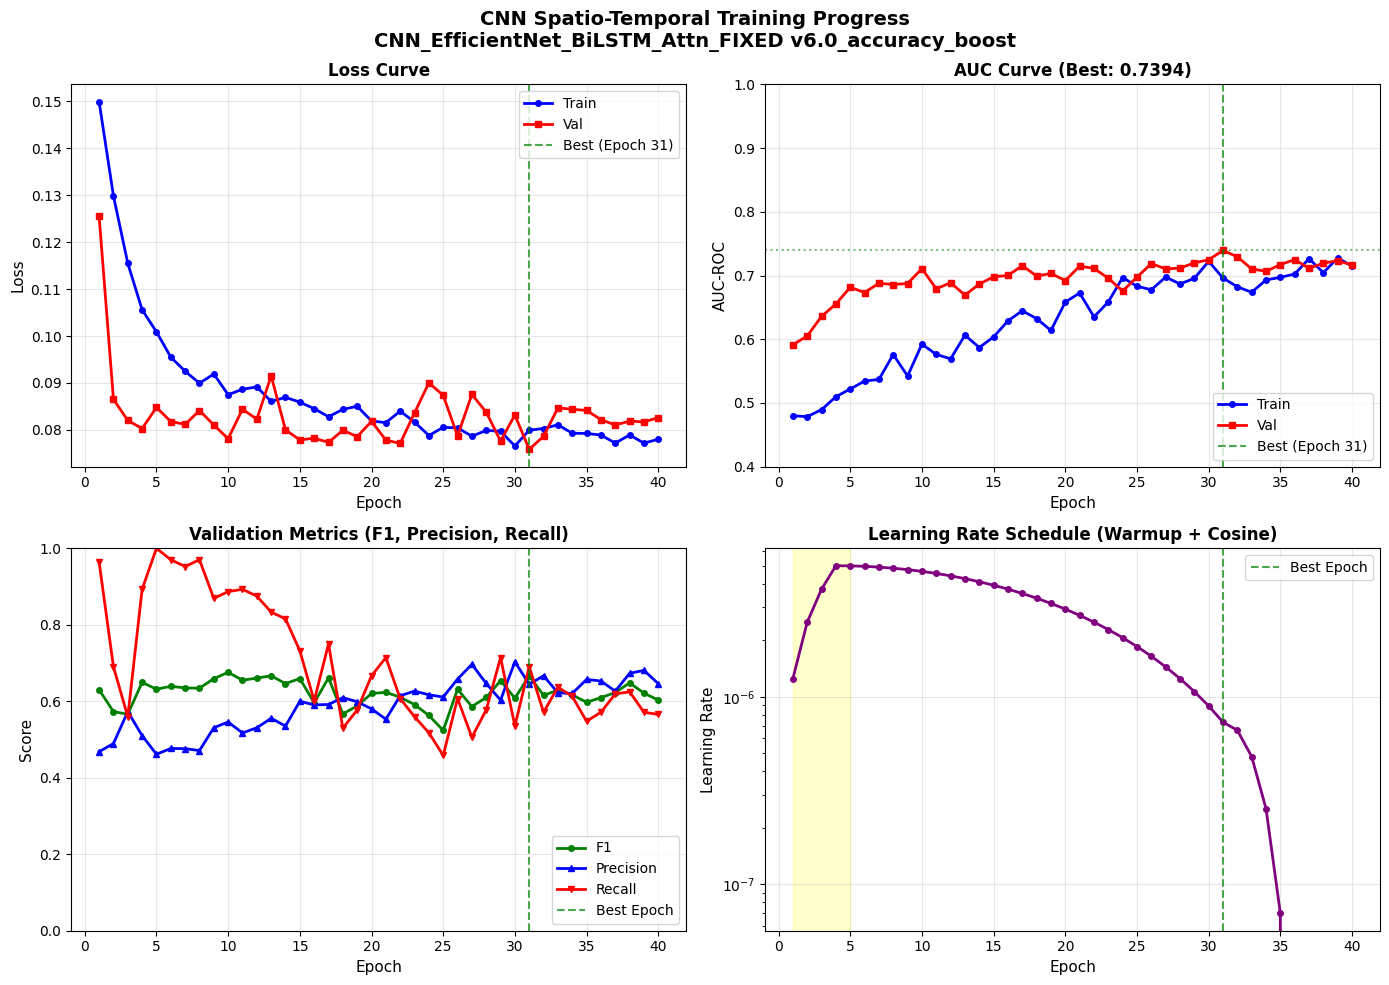

In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING CURVES (Research-Grade Visualization))
# ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = range(1, len(history['train_loss']) + 1)

# 1. Loss Curve
axes[0, 0].plot(epochs, history['train_loss'], 'b-', marker='o', label='Train', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, history['val_loss'], 'r-', marker='s', label='Val', linewidth=2, markersize=4)
axes[0, 0].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best (Epoch {best_epoch})')
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Loss', fontsize=11)
axes[0, 0].set_title('Loss Curve', fontsize=12, fontweight='bold')
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

# 2. AUC Curve
axes[0, 1].plot(epochs, history['train_auc'], 'b-', marker='o', label='Train', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, history['val_auc'], 'r-', marker='s', label='Val', linewidth=2, markersize=4)
axes[0, 1].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best (Epoch {best_epoch})')
axes[0, 1].axhline(y=best_val_auc, color='green', linestyle=':', alpha=0.5)
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('AUC-ROC', fontsize=11)
axes[0, 1].set_title(f'AUC Curve (Best: {best_val_auc:.4f})', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.4, 1.0])

# 3. F1 / Precision / Recall
axes[1, 0].plot(epochs, history['val_f1'], 'g-', marker='o', label='F1', linewidth=2, markersize=4)
axes[1, 0].plot(epochs, history['val_precision'], 'b-', marker='^', label='Precision', linewidth=2, markersize=4)
axes[1, 0].plot(epochs, history['val_recall'], 'r-', marker='v', label='Recall', linewidth=2, markersize=4)
axes[1, 0].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch')
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('Score', fontsize=11)
axes[1, 0].set_title('Validation Metrics (F1, Precision, Recall)', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0.0, 1.0])

# 4. Learning Rate Schedule
axes[1, 1].plot(epochs, history['lr'], 'purple', marker='o', linewidth=2, markersize=4)
axes[1, 1].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch')
axes[1, 1].set_xlabel('Epoch', fontsize=11)
axes[1, 1].set_ylabel('Learning Rate', fontsize=11)
axes[1, 1].set_title('Learning Rate Schedule (Warmup + Cosine)', fontsize=12, fontweight='bold')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(loc='upper right')

# Add warmup region annotation
if len(history['lr']) > 1:
    warmup_end_epoch = int(cfg.WARMUP_RATIO * cfg.NUM_EPOCHS) + 1
    if warmup_end_epoch > 0 and warmup_end_epoch < len(epochs):
        axes[1, 1].axvspan(1, warmup_end_epoch, alpha=0.2, color='yellow', label='Warmup Phase')

plt.suptitle(f'CNN Spatio-Temporal Training Progress\n{cfg.EXPERIMENT_NAME} {cfg.EXPERIMENT_VERSION}', 
             fontsize=14, fontweight='bold')
plt.tight_layout()

# Save figure
fig_path = os.path.join(cfg.OUTPUT_DIR, f'training_curves_fold{cfg.CURRENT_FOLD}.png' if cfg.CURRENT_FOLD >= 0 else 'training_curves.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight', facecolor='white')
print(f"✓ Training curves saved to: {fig_path}")

plt.show()


## 6. Video-Level Inference & Export

In [23]:
# ═══════════════════════════════════════════════════════════════════════
# LOAD BEST MODEL
# ═══════════════════════════════════════════════════════════════════════

possible_names = [
    f"best_cnn_model_fold{cfg.CURRENT_FOLD}.pth" if cfg.CURRENT_FOLD >= 0 else "",
    "best_cnn_model.pth",
]

model_path = None
for name in possible_names:
    if not name:
        continue
    temp = os.path.join(cfg.OUTPUT_DIR, name)
    if os.path.exists(temp):
        model_path = temp
        break

if model_path is None:
    pth_files = [f for f in os.listdir(cfg.OUTPUT_DIR) if f.endswith('.pth')]
    if pth_files:
        model_path = os.path.join(cfg.OUTPUT_DIR, pth_files[0])
    else:
        raise FileNotFoundError("No .pth model found. Run training cell first.")

model.load_state_dict(torch.load(model_path, map_location=DEVICE, weights_only=True))
model.eval()
print(f"✓ Best model loaded from: {model_path}")

✓ Best model loaded from: /kaggle/working/best_cnn_model_fold0.pth


In [24]:
import cv2

def predict_video_temporal(model, cache_path: str, transform,
                            device, max_frames=20):
    """Predict deepfake probability using 5-Pass TTA and proper padding mask."""
    model.eval()

    if not os.path.exists(cache_path): return 0.5
    faces = np.load(cache_path)  
    if len(faces) < 3: return 0.5

    n = len(faces)
    step = n / max_frames if n >= max_frames else 1
    indices = [int(i * step) for i in range(max_frames)] if n >= max_frames else list(range(n))
    while len(indices) < max_frames: indices.append(n - 1)

    selected = [faces[i].astype('uint8') for i in indices]

    # Helper function for TTA passes (uses additional_targets for consistency)
    def run_pass(frames_list):
        transform_kwargs = {'image': frames_list[0]}
        for k in range(1, len(frames_list)):
            transform_kwargs[f'image{k}'] = frames_list[k]
        augmented = transform(**transform_kwargs)
        frame_tensors = [augmented['image']]
        for k in range(1, len(frames_list)):
            frame_tensors.append(augmented[f'image{k}'])
        fstack = torch.stack(frame_tensors).unsqueeze(0).to(device)
        
        # 🚨 FIX: Calculate actual length and apply proper padding mask
        actual_len = min(n, max_frames)
        mask = torch.zeros(1, max_frames, dtype=torch.bool).to(device)
        mask[0, :actual_len] = True
        
        with torch.no_grad():
            logit = model(fstack, mask)
            return torch.sigmoid(logit).item()

    probs = []
    # Pass 1: standard
    probs.append(run_pass(selected))
    
    # Pass 2: horizontal flip
    probs.append(run_pass([np.fliplr(f).copy() for f in selected]))
    
    # Pass 3: brightness up
    probs.append(run_pass([np.clip(f.astype(np.int32)+15, 0, 255).astype(np.uint8) for f in selected]))
    
    # Pass 4: brightness down
    probs.append(run_pass([np.clip(f.astype(np.int32)-15, 0, 255).astype(np.uint8) for f in selected]))
    
    # Pass 5: slight blur (compression simulation)
    probs.append(run_pass([cv2.GaussianBlur(f, (3,3), 0) for f in selected]))

    del faces
    
    # Return uniform average of all 5 passes
    return float(np.mean(probs))


def generate_video_predictions(model, videos, cache_index,
                                transform, device):
    """Generate predictions for all videos using disk cache."""
    predictions = []

    for video in tqdm(videos, desc="Predicting"):
        vid_id = video['video_id']
        if vid_id in cache_index:
            prob = predict_video_temporal(
                model, cache_index[vid_id],
                transform, device, cfg.FRAMES_PER_VIDEO)
        else:
            prob = 0.5
        predictions.append({
            'video_id'       : vid_id,
            'label'          : video['label'],
            'prediction'     : prob,
            'predicted_class': 1 if prob > 0.5 else 0,
            'source'         : video.get('source', 'unknown')
        })

    return predictions

print("✓ Prediction functions updated with 5-Pass TTA + proper padding mask")


✓ Prediction functions updated with 5-Pass TTA + proper padding mask


In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1: EXECUTE VIDEO-LEVEL PREDICTIONS (MUST RUN FIRST)
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("GENERATING FINAL VIDEO-LEVEL PREDICTIONS")
print("="*70)

# 1. Load the best model weights
best_model_path = os.path.join(
    cfg.OUTPUT_DIR,
    f"best_cnn_model_fold{cfg.CURRENT_FOLD}.pth"
    if cfg.CURRENT_FOLD >= 0 else "best_cnn_model.pth"
)
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=True))
    #                                 ^^^^^^^^^^^^^^^ FIXED: use best_model_path, not model_path
    print(f"✓ Loaded best model from: {best_model_path}")
else:
    print(f"⚠️ No saved model found at {best_model_path}, using current model state")

# 2. Generate predictions
model.eval()
raw_preds = generate_video_predictions(model, val_videos, cache_index, get_val_transforms(), DEVICE)

# 3. Create predictions DataFrame (CRITICAL - used by all subsequent cells)
predictions_df = pd.DataFrame(raw_preds)
predictions_df.rename(columns={'prediction': 'P_CNN'}, inplace=True)

# 4. Create the metric variables
y_true = predictions_df['label'].values
y_pred_proba = predictions_df['P_CNN'].values
y_pred = (y_pred_proba > 0.5).astype(int)

# 5. Calculate basic metrics
video_acc = accuracy_score(y_true, y_pred)
video_f1 = f1_score(y_true, y_pred, zero_division=0)
video_precision = precision_score(y_true, y_pred, zero_division=0)
video_recall = recall_score(y_true, y_pred, zero_division=0)

if len(np.unique(y_true)) > 1:
    video_auc = roc_auc_score(y_true, y_pred_proba)
    video_eer = compute_eer(y_true, y_pred_proba)
else:
    video_auc = 0.5
    video_eer = 0.5
    print("⚠️ Single class in validation set - AUC/EER defaulted to 0.5")

# 6. Find optimal threshold
optimal_thresh, optimal_f1 = find_optimal_threshold(y_true, y_pred_proba)
y_pred_optimal = (y_pred_proba >= optimal_thresh).astype(int)
video_acc_optimal = accuracy_score(y_true, y_pred_optimal)
video_f1_optimal = f1_score(y_true, y_pred_optimal, zero_division=0)

# 7. Save predictions
csv_path = os.path.join(cfg.OUTPUT_DIR, "cnn_predictions.csv")
predictions_df.to_csv(csv_path, index=False)

print(f"\n✓ Predictions saved to: {csv_path}")
print(f"  Videos predicted: {len(predictions_df)}")
print(f"\n{'─'*50}")
print("METRICS (threshold=0.5):")
print(f"  AUC-ROC:   {video_auc:.4f}")
print(f"  Accuracy:  {video_acc:.4f}")
print(f"  F1-Score:  {video_f1:.4f}")
print(f"  Precision: {video_precision:.4f}")
print(f"  Recall:    {video_recall:.4f}")
print(f"  EER:       {video_eer:.4f}")
print(f"\n{'─'*50}")
print(f"OPTIMAL THRESHOLD = {optimal_thresh:.2f}:")
print(f"  Accuracy:  {video_acc_optimal:.4f}")
print(f"  F1-Score:  {video_f1_optimal:.4f}")


GENERATING FINAL VIDEO-LEVEL PREDICTIONS
✓ Loaded best model from: /kaggle/working/best_cnn_model_fold0.pth


Predicting:   0%|          | 0/367 [00:00<?, ?it/s]


✓ Predictions saved to: /kaggle/working/cnn_predictions.csv
  Videos predicted: 367

──────────────────────────────────────────────────
METRICS (threshold=0.5):
  AUC-ROC:   0.7390
  Accuracy:  0.6921
  F1-Score:  0.6762
  Precision: 0.6519
  Recall:    0.7024
  EER:       0.3015

──────────────────────────────────────────────────
OPTIMAL THRESHOLD = 0.48:
  Accuracy:  0.6839
  F1-Score:  0.6882


In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 2: BOOTSTRAP CONFIDENCE INTERVALS (Research Requirement)
# ═══════════════════════════════════════════════════════════════════════════════

def bootstrap_ci(y_true, y_pred, metric_fn, n_bootstrap=1000, ci=95, seed=42):
    """Compute bootstrap confidence intervals for a metric."""
    rng = np.random.RandomState(seed)
    n = len(y_true)
    scores = []
    for _ in range(n_bootstrap):
        indices = rng.randint(0, n, n)
        y_true_boot = y_true[indices]
        y_pred_boot = y_pred[indices]
        if len(np.unique(y_true_boot)) < 2:
            continue
        try:
            scores.append(metric_fn(y_true_boot, y_pred_boot))
        except Exception:
            continue
    if len(scores) == 0:
        point = metric_fn(y_true, y_pred)
        return point, point, point
    scores = np.array(scores)
    alpha = (100 - ci) / 2
    return np.percentile(scores, alpha), metric_fn(y_true, y_pred), np.percentile(scores, 100 - alpha)

print("\n" + "="*70)
print("BOOTSTRAP CONFIDENCE INTERVALS (1000 iterations)")
print("="*70)

auc_low, auc_mid, auc_high = bootstrap_ci(y_true, y_pred_proba, roc_auc_score)
acc_low, acc_mid, acc_high = bootstrap_ci(y_true, y_pred, accuracy_score)
f1_low, f1_mid, f1_high   = bootstrap_ci(y_true, y_pred, f1_score)
# FIXED: EER now also has bootstrap CI
eer_low, eer_mid, eer_high = bootstrap_ci(y_true, y_pred_proba, compute_eer)

print(f"\n  AUC-ROC:   {auc_mid:.4f} [95% CI: {auc_low:.4f}, {auc_high:.4f}]")
print(f"  Accuracy:  {acc_mid:.4f} [95% CI: {acc_low:.4f}, {acc_high:.4f}]")
print(f"  F1-Score:  {f1_mid:.4f} [95% CI: {f1_low:.4f}, {f1_high:.4f}]")
print(f"  EER:       {eer_mid:.4f} [95% CI: {eer_low:.4f}, {eer_high:.4f}]")

# Save metrics with CI — all 4 metrics now have intervals
metrics_df = pd.DataFrame([
    {'metric': 'AUC-ROC',  'value': auc_mid,  'ci_low': auc_low,  'ci_high': auc_high},
    {'metric': 'Accuracy', 'value': acc_mid,  'ci_low': acc_low,  'ci_high': acc_high},
    {'metric': 'F1-Score', 'value': f1_mid,   'ci_low': f1_low,   'ci_high': f1_high},
    {'metric': 'EER',      'value': eer_mid,  'ci_low': eer_low,  'ci_high': eer_high},
])
metrics_df.to_csv(os.path.join(cfg.OUTPUT_DIR, "cnn_metrics_with_ci.csv"), index=False)
print(f"\n✓ Metrics with 95% CI saved to: cnn_metrics_with_ci.csv")


BOOTSTRAP CONFIDENCE INTERVALS (1000 iterations)

  AUC-ROC:   0.7390 [95% CI: 0.6838, 0.7857]
  Accuracy:  0.6921 [95% CI: 0.6431, 0.7358]
  F1-Score:  0.6762 [95% CI: 0.6144, 0.7283]
  EER:       0.3015 [95% CI: 0.2664, 0.3641]

✓ Metrics with 95% CI saved to: cnn_metrics_with_ci.csv


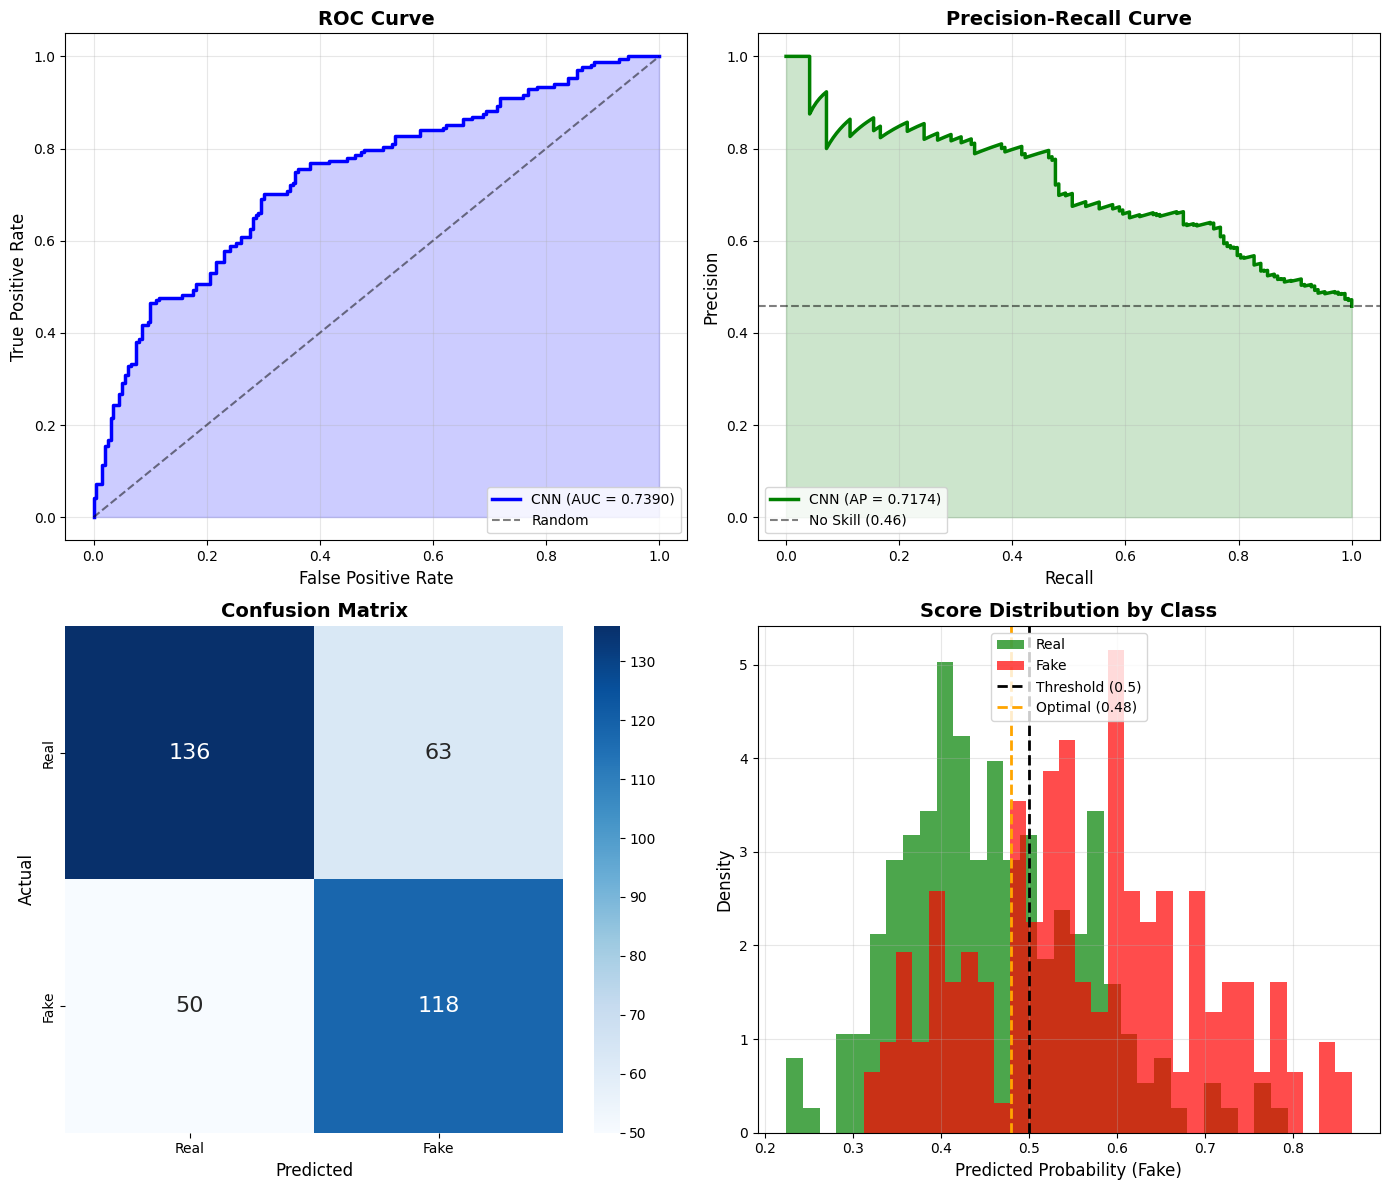


✓ Evaluation plots saved to: cnn_evaluation_plots.png

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Real     0.7312    0.6834    0.7065       199
        Fake     0.6519    0.7024    0.6762       168

    accuracy                         0.6921       367
   macro avg     0.6916    0.6929    0.6914       367
weighted avg     0.6949    0.6921    0.6926       367



In [27]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 3: RESEARCH-GRADE VISUALIZATIONS
# ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score, roc_curve
import seaborn as sns

# Prepare data
real_preds = predictions_df[predictions_df['label'] == 0]['P_CNN']
fake_preds = predictions_df[predictions_df['label'] == 1]['P_CNN']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
axes[0, 0].plot(fpr, tpr, 'b-', linewidth=2.5, label=f'CNN (AUC = {video_auc:.4f})')
axes[0, 0].fill_between(fpr, tpr, alpha=0.2, color='blue')
axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1.5, label='Random')
axes[0, 0].set_xlabel('False Positive Rate', fontsize=12)
axes[0, 0].set_ylabel('True Positive Rate', fontsize=12)
axes[0, 0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(True, alpha=0.3)

# 2. Precision-Recall Curve
precision_arr, recall_arr, _ = precision_recall_curve(y_true, y_pred_proba)
ap = average_precision_score(y_true, y_pred_proba)
axes[0, 1].plot(recall_arr, precision_arr, 'g-', linewidth=2.5, label=f'CNN (AP = {ap:.4f})')
axes[0, 1].fill_between(recall_arr, precision_arr, alpha=0.2, color='green')
axes[0, 1].axhline(y=y_true.mean(), color='k', linestyle='--', alpha=0.5, label=f'No Skill ({y_true.mean():.2f})')
axes[0, 1].set_xlabel('Recall', fontsize=12)
axes[0, 1].set_ylabel('Precision', fontsize=12)
axes[0, 1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc='lower left')
axes[0, 1].grid(True, alpha=0.3)

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
            annot_kws={'size': 16})
axes[1, 0].set_xlabel('Predicted', fontsize=12)
axes[1, 0].set_ylabel('Actual', fontsize=12)
axes[1, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# 4. Score Distribution
axes[1, 1].hist(real_preds, bins=30, alpha=0.7, label='Real', color='green', density=True)
axes[1, 1].hist(fake_preds, bins=30, alpha=0.7, label='Fake', color='red', density=True)
axes[1, 1].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
axes[1, 1].axvline(x=optimal_thresh, color='orange', linestyle='--', linewidth=2, label=f'Optimal ({optimal_thresh:.2f})')
axes[1, 1].set_xlabel('Predicted Probability (Fake)', fontsize=12)
axes[1, 1].set_ylabel('Density', fontsize=12)
axes[1, 1].set_title('Score Distribution by Class', fontsize=14, fontweight='bold')
axes[1, 1].legend(loc='upper center')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'cnn_evaluation_plots.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Evaluation plots saved to: cnn_evaluation_plots.png")

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake'], digits=4))



GENERATING GRAD-CAM VISUALIZATIONS


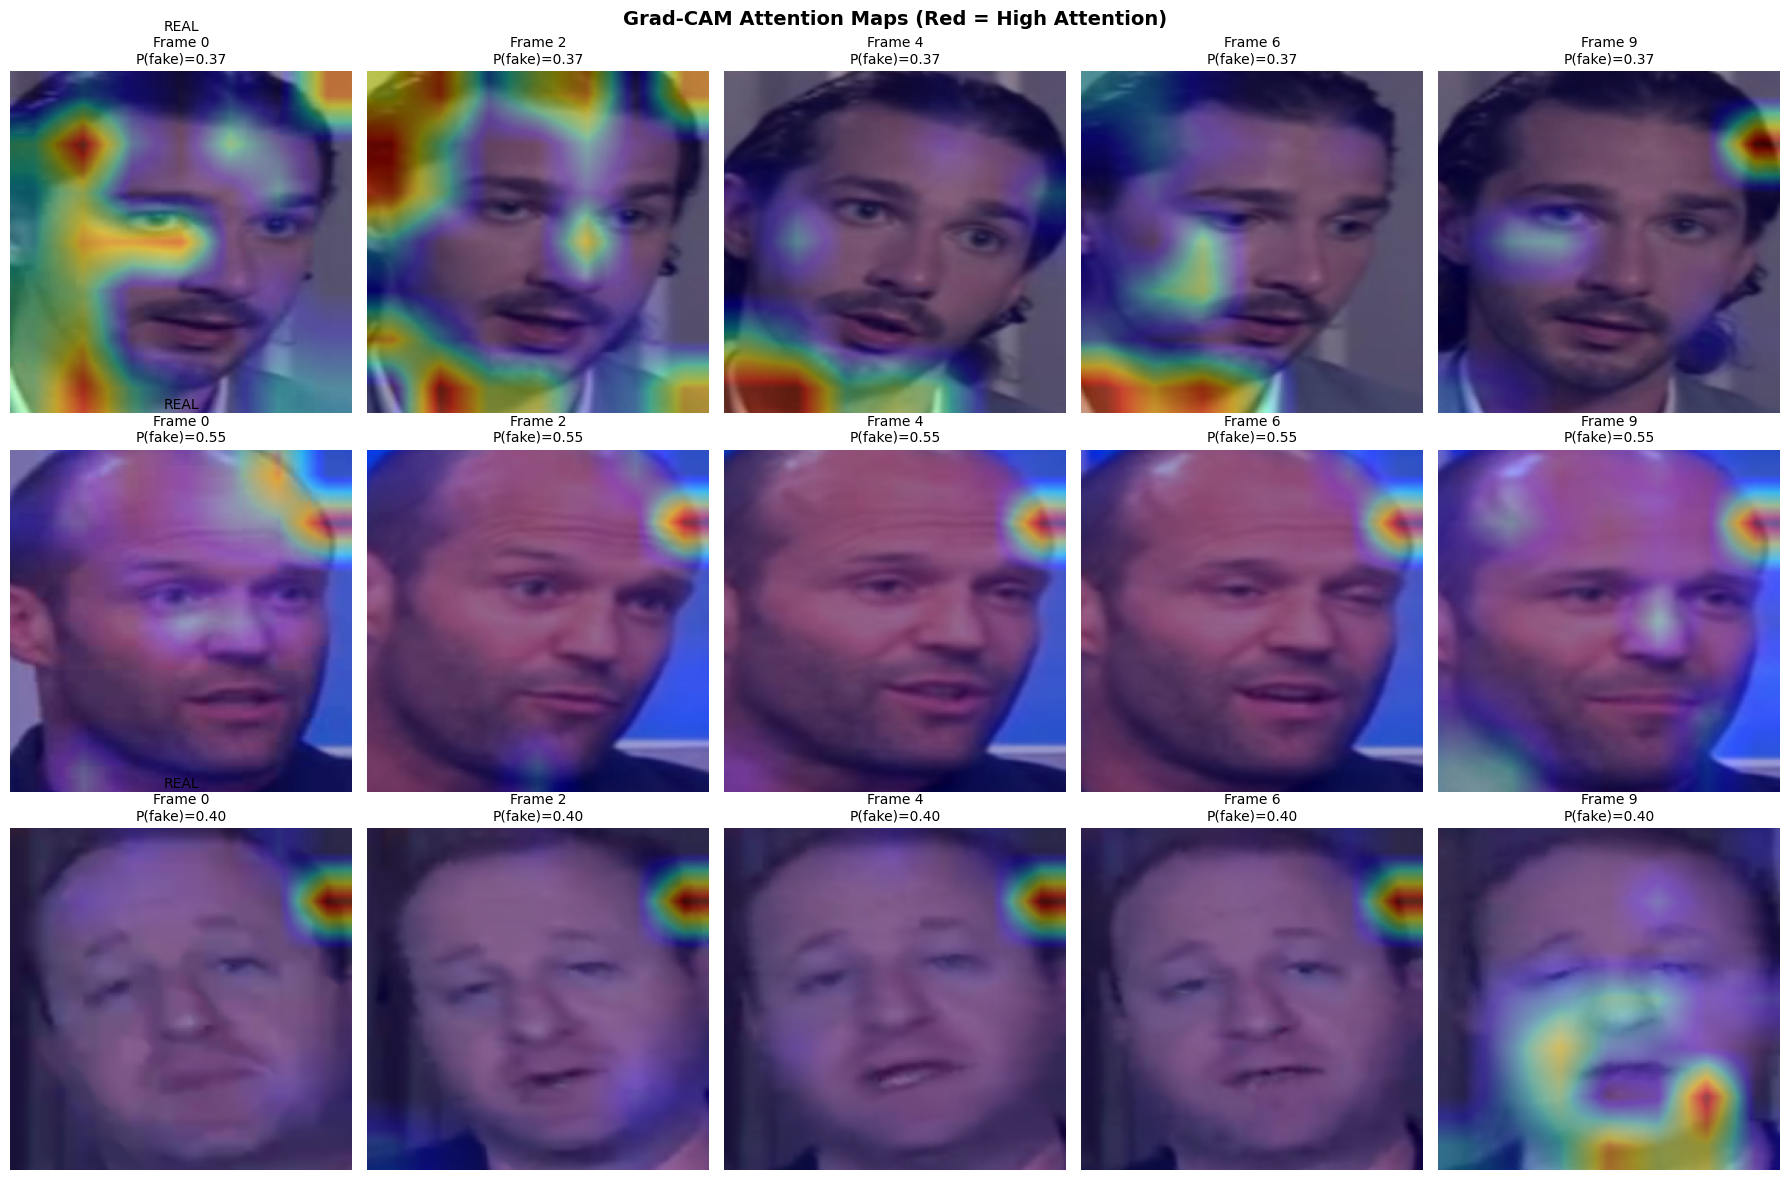


✓ Grad-CAM visualization saved: gradcam_gallery.png
  Videos shown: 3 of 3 available


In [28]:
# ═══════════════════════════════════════════════════════════════════════
# STEP 4: GRAD-CAM VISUALIZATION (Research Requirement)
# Fixed: uses cache_index (not face_data), 20 frames, P100-safe numpy
# ═══════════════════════════════════════════════════════════════════════

import torch.nn.functional as F

class SimpleGradCAM:
    """Grad-CAM for temporal models — P100 safe."""
    
    def __init__(self, cnn_model):
        self.model      = cnn_model
        self.gradients  = None
        self.activations = None
        self.handles    = []
        target_layer    = self.model.backbone.conv_head
        self.handles.append(target_layer.register_forward_hook(self._save_activation))
        self.handles.append(target_layer.register_full_backward_hook(self._save_gradient))

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def cleanup(self):
        for h in self.handles:
            h.remove()
        self.handles = []

    def generate(self, frames, mask, target_frame_idx=0):
        self.model.eval()

        logit = self.model(frames, mask)
        prob = torch.sigmoid(logit).detach().item()

        self.model.zero_grad()
        logit.squeeze().backward(retain_graph=True)

        if self.gradients is None or self.activations is None:
            return np.zeros(frames.shape[3:]), prob

        target_grads = self.gradients[target_frame_idx:target_frame_idx + 1]
        target_acts  = self.activations[target_frame_idx:target_frame_idx + 1]

        weights = target_grads.mean(dim=(2, 3), keepdim=True)
        cam     = F.relu((weights * target_acts).sum(dim=1, keepdim=True))

        if cam.max() - cam.min() > 1e-8:
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        else:
            cam = torch.zeros_like(cam)

        cam = F.interpolate(cam, size=frames.shape[3:],
                            mode='bilinear', align_corners=False)

        # P100 FIX: use .tolist() NOT .numpy() — avoids C-API crash
        cam_numpy = np.array(cam.squeeze().cpu().tolist())
        return cam_numpy, prob


print("\n" + "="*70)
print("GENERATING GRAD-CAM VISUALIZATIONS")
print("="*70)



gradcam = SimpleGradCAM(model)

# Collect up to 3 valid videos first, THEN draw the figure
valid_videos_for_gradcam = []
for video in val_videos:
    if len(valid_videos_for_gradcam) >= 3:
        break
    vid_id = video['video_id']
    if vid_id not in cache_index:
        continue
    faces_check = np.load(cache_index[vid_id])
    if len(faces_check) < 5:
        del faces_check
        continue
    valid_videos_for_gradcam.append(video)
    del faces_check

n_videos_to_show = len(valid_videos_for_gradcam)
frame_indices = [0, 2, 4, 6, 9]  # 5 frames from 20-frame sequence

if n_videos_to_show == 0:
    print("⚠️  WARNING: No valid videos found for Grad-CAM visualization.")
    print("   Possible causes: cache_index empty, all videos have <5 faces.")
    gradcam.cleanup()
else:
    # Create figure with EXACT number of rows needed — no blank rows
    fig, axes = plt.subplots(n_videos_to_show, 5,
                              figsize=(18, 4 * n_videos_to_show))
    # Ensure axes is always 2D even when n_videos_to_show == 1
    if n_videos_to_show == 1:
        axes = axes[np.newaxis, :]

    videos_shown = 0
    for video in valid_videos_for_gradcam:
        vid_id = video['video_id']
        faces  = np.load(cache_index[vid_id])
        label  = video['label']

        n_faces = len(faces)
        if n_faces >= cfg.FRAMES_PER_VIDEO:
            step    = n_faces / cfg.FRAMES_PER_VIDEO
            indices = [int(i * step) for i in range(cfg.FRAMES_PER_VIDEO)]
        else:
            indices = list(range(n_faces))
            while len(indices) < cfg.FRAMES_PER_VIDEO:
                indices.append(n_faces - 1)

        selected_faces = [faces[i].astype('uint8') for i in indices]

        val_tf = get_val_transforms(max_frames=len(selected_faces))
        gc_kwargs = {'image': selected_faces[0]}
        for k in range(1, len(selected_faces)):
            gc_kwargs[f'image{k}'] = selected_faces[k]
        gc_aug = val_tf(**gc_kwargs)
        frame_tensors = [gc_aug['image']]
        for k in range(1, len(selected_faces)):
            frame_tensors.append(gc_aug[f'image{k}'])

        input_frames = torch.stack(frame_tensors).unsqueeze(0).to(DEVICE)
        input_mask   = torch.ones(1, cfg.FRAMES_PER_VIDEO,
                                  dtype=torch.bool).to(DEVICE)

        for col, f_idx in enumerate(frame_indices):
            heatmap, prob = gradcam.generate(
                input_frames.clone(), input_mask, target_frame_idx=f_idx)

            face_img = selected_faces[f_idx]
            axes[videos_shown, col].imshow(face_img)
            axes[videos_shown, col].imshow(heatmap, cmap='jet', alpha=0.4)

            title = f"Frame {f_idx}\nP(fake)={prob:.2f}"
            if col == 0:
                title = f"{'FAKE' if label==1 else 'REAL'}\n{title}"
            axes[videos_shown, col].set_title(title, fontsize=10)
            axes[videos_shown, col].axis('off')

        del faces
        videos_shown += 1

    gradcam.cleanup()

    plt.suptitle('Grad-CAM Attention Maps (Red = High Attention)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'gradcam_gallery.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✓ Grad-CAM visualization saved: gradcam_gallery.png")
    print(f"  Videos shown: {videos_shown} of {n_videos_to_show} available")

## 7. Late Fusion Integration Guide

In [29]:
# ═══════════════════════════════════════════════════════════════════════════════
# LATE FUSION INTEGRATION GUIDE
# ═══════════════════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                       LATE FUSION INTEGRATION GUIDE                          ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  This notebook outputs: cnn_predictions.csv                                  ║
║  Columns: video_id, P_CNN                                                    ║
║                                                                              ║
║  To fuse with rPPG predictions from 2ND_MODEL.ipynb:                        ║
║                                                                              ║
║  ┌─────────────────────────────────────────────────────────────────────────┐ ║
║  │  # Load both predictions                                                │ ║
║  │  cnn_df = pd.read_csv('cnn_predictions.csv')                           │ ║
║  │  rppg_df = pd.read_csv('rppg_predictions.csv')                         │ ║
║  │                                                                         │ ║
║  │  # Merge on video_id                                                    │ ║
║  │  fused_df = cnn_df.merge(rppg_df, on='video_id')                       │ ║
║  │                                                                         │ ║
║  │  # Simple average fusion                                                │ ║
║  │  fused_df['P_final'] = (fused_df['P_CNN'] + fused_df['P_rPPG']) / 2    │ ║
║  │                                                                         │ ║
║  │  # Weighted fusion (if CNN is more accurate)                           │ ║
║  │  w_cnn, w_rppg = 0.6, 0.4                                              │ ║
║  │  fused_df['P_final'] = w_cnn * fused_df['P_CNN']                       │ ║
║  │                      + w_rppg * fused_df['P_rPPG']                      │ ║
║  │                                                                         │ ║
║  │  # Learned fusion (train a small classifier)                           │ ║
║  │  from sklearn.linear_model import LogisticRegression                   │ ║
║  │  X_fusion = fused_df[['P_CNN', 'P_rPPG']].values                       │ ║
║  │  y_fusion = fused_df['label'].values                                   │ ║
║  │  fusion_model = LogisticRegression().fit(X_fusion, y_fusion)           │ ║
║  │  fused_df['P_final'] = fusion_model.predict_proba(X_fusion)[:, 1]      │ ║
║  └─────────────────────────────────────────────────────────────────────────┘ ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║                       LATE FUSION INTEGRATION GUIDE                          ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  This notebook outputs: cnn_predictions.csv                                  ║
║  Columns: video_id, P_CNN                                                    ║
║                                                                              ║
║  To fuse with rPPG predictions from 2ND_MODEL.ipynb:                        ║
║                                                                              ║
║  ┌─────────────────────────────────────────────────────────────────────────┐ ║
║  │  # Load both predictions                                                │ ║
║  │  cnn_df = pd.read_csv('cnn_predictions.csv')                           │ ║
║  │  rppg_df = pd.read_csv('

In [30]:
# ═══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("CNN SPATIO-TEMPORAL STREAM — FINAL SUMMARY")
print("="*70)

# Get parameter counts (handle both variable names)
total = total_params if 'total_params' in vars() else sum(p.numel() for p in model.parameters())
trainable_count = trainable if 'trainable' in vars() else sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│  ARCHITECTURE                                                               │
├─────────────────────────────────────────────────────────────────────────────┤
│  Backbone:           EfficientNet-B4 (ImageNet pretrained)                  │
│  Temporal Model:     BiLSTM + Multi-Head Self-Attention                     │
│  LSTM Hidden:        {cfg.LSTM_HIDDEN} × 2 (bidirectional)                                │
│  LSTM Layers:        {cfg.LSTM_LAYERS}                                                     │
│  Attention Heads:    {cfg.ATTENTION_HEADS}                                                     │
│  Total Parameters:   {total:,}                                       │
│  Trainable Params:   {trainable_count:,}                                       │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  TRAINING CONFIGURATION                                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│  Training Videos:    {len(train_videos)}                                                       │
│  Validation Videos:  {len(val_videos)}                                                       │
│  Frames per Video:   {cfg.FRAMES_PER_VIDEO}                                                        │
│  Batch Size:         {cfg.BATCH_SIZE} (effective: {cfg.BATCH_SIZE * cfg.GRAD_ACCUMULATION_STEPS})                                         │
│  Learning Rate:      {cfg.LEARNING_RATE}                                                    │
│  Loss Function:      Focal Loss (α={cfg.FOCAL_ALPHA}, γ={cfg.FOCAL_GAMMA})                              │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  BEST FRAME-LEVEL RESULTS                                                   │
├─────────────────────────────────────────────────────────────────────────────┤
│  Best Epoch:         {best_epoch}                                                        │
│  Best Val AUC:       {best_val_auc:.4f}                                                    │
│  Best Val EER:       {best_val_eer:.4f}                                                    │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  VIDEO-LEVEL METRICS (Final Evaluation)                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│  AUC-ROC:            {video_auc:.4f}                                                    │
│  Accuracy:           {video_acc:.4f}                                                    │
│  F1-Score:           {video_f1:.4f}                                                    │
│  EER:                {video_eer:.4f}                                                    │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  OUTPUT FILES                                                               │
├─────────────────────────────────────────────────────────────────────────────┤
│  ✓ cnn_predictions.csv          (video-level P_CNN scores for Late Fusion) │
│  ✓ best_cnn_model.pth           (best checkpoint weights)                  │
│  ✓ cnn_spatial_stream_final.pth (final model weights)                      │
│  ✓ cnn_training_history.csv     (epoch-by-epoch metrics)                   │
│  ✓ cnn_config.csv               (hyperparameters & final results)          │
└─────────────────────────────────────────────────────────────────────────────┘
""")


# Save final model weights (distinct from best checkpoint)
final_model_path = os.path.join(cfg.OUTPUT_DIR, "cnn_spatial_stream_final.pth")
torch.save(model.state_dict(), final_model_path)
print(f"✓ Final model saved: {final_model_path}")

# Save config as CSV for paper reproducibility
config_csv_path = os.path.join(cfg.OUTPUT_DIR, "cnn_config.csv")
pd.DataFrame([cfg.to_dict()]).to_csv(config_csv_path, index=False)
print(f"✓ Config saved as CSV: {config_csv_path}")


print("="*70)
print("✅ CNN SPATIO-TEMPORAL STREAM TRAINING COMPLETE!")
print("="*70)
print("\n  Key achievements:")
print("  ✓ Temporal modeling via BiLSTM + Multi-Head Attention")
print("  ✓ Detects inter-frame artifacts (flickering, blending shifts)")
print("  ✓ P100 compatible (FP32 only, no AMP)")
print("  ✓ Ready for Late Fusion with rPPG physiological stream")
print("\n  Next step:")
print("  → Run final_MODEL_rppg.ipynb to get P_rPPG scores")
print("  → Combine P_CNN + P_rPPG for Late Fusion ensemble")
print("="*70)




CNN SPATIO-TEMPORAL STREAM — FINAL SUMMARY

┌─────────────────────────────────────────────────────────────────────────────┐
│  ARCHITECTURE                                                               │
├─────────────────────────────────────────────────────────────────────────────┤
│  Backbone:           EfficientNet-B4 (ImageNet pretrained)                  │
│  Temporal Model:     BiLSTM + Multi-Head Self-Attention                     │
│  LSTM Hidden:        256 × 2 (bidirectional)                                │
│  LSTM Layers:        2                                                     │
│  Attention Heads:    4                                                     │
│  Total Parameters:   24,540,745                                       │
│  Trainable Params:   24,540,745                                       │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  TRAIN

In [31]:
import os
working_files = os.listdir('/kaggle/working/')
print("Files currently in the working directory:", working_files)

Files currently in the working directory: ['best_cnn_model_fold0.pth', 'cnn_spatial_stream_final.pth', 'training_curves_fold0.png', 'cnn_evaluation_plots.png', 'gradcam_gallery.png', 'training_history_fold0.json', 'swa_model_fold0.pth', 'cnn_predictions.csv', 'cnn_metrics_with_ci.csv', '__notebook__.ipynb', 'face_cache', 'master_dataset_index.csv', 'cache_index.json', 'cnn_config.csv', 'config.json']


In [32]:
import os

print("--- TRUE DISK FILE SIZES ---")
for f in os.listdir('/kaggle/working/'):
    path = os.path.join('/kaggle/working/', f)
    if os.path.isfile(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"{f}: {size_mb:.2f} MB")

--- TRUE DISK FILE SIZES ---
best_cnn_model_fold0.pth: 94.36 MB
cnn_spatial_stream_final.pth: 94.36 MB
training_curves_fold0.png: 0.36 MB
cnn_evaluation_plots.png: 0.17 MB
gradcam_gallery.png: 2.78 MB
training_history_fold0.json: 0.01 MB
swa_model_fold0.pth: 94.36 MB
cnn_predictions.csv: 0.02 MB
cnn_metrics_with_ci.csv: 0.00 MB
__notebook__.ipynb: 2.68 MB
master_dataset_index.csv: 0.22 MB
cache_index.json: 0.15 MB
cnn_config.csv: 0.00 MB
config.json: 0.00 MB


In [33]:
import os

bad_zip = '/kaggle/working/cnn_clean_outputs.zip'

if os.path.exists(bad_zip):
    os.remove(bad_zip)
    print(f"🗑️ Successfully deleted: {bad_zip}")
    print("Disk space freed!")
else:
    print(f"The file {bad_zip} was not found. It may have already been deleted.")

# Verify what is left
print("\nCurrent safe files remaining:")
print([f for f in os.listdir('/kaggle/working/') if not f.startswith('.')])

The file /kaggle/working/cnn_clean_outputs.zip was not found. It may have already been deleted.

Current safe files remaining:
['best_cnn_model_fold0.pth', 'cnn_spatial_stream_final.pth', 'training_curves_fold0.png', 'cnn_evaluation_plots.png', 'gradcam_gallery.png', 'training_history_fold0.json', 'swa_model_fold0.pth', 'cnn_predictions.csv', 'cnn_metrics_with_ci.csv', '__notebook__.ipynb', 'face_cache', 'master_dataset_index.csv', 'cache_index.json', 'cnn_config.csv', 'config.json']


In [34]:
import os

bad_zip = '/kaggle/working/cnn_clean_outputs.zip'

if os.path.exists(bad_zip):
    os.remove(bad_zip)
    print(f"🗑️ Successfully deleted: {bad_zip}")
    print("Disk space freed!")
else:
    print(f"The file {bad_zip} was not found. It may have already been deleted.")

# Verify what is left
print("\nCurrent safe files remaining:")
print([f for f in os.listdir('/kaggle/working/') if not f.startswith('.')])

The file /kaggle/working/cnn_clean_outputs.zip was not found. It may have already been deleted.

Current safe files remaining:
['best_cnn_model_fold0.pth', 'cnn_spatial_stream_final.pth', 'training_curves_fold0.png', 'cnn_evaluation_plots.png', 'gradcam_gallery.png', 'training_history_fold0.json', 'swa_model_fold0.pth', 'cnn_predictions.csv', 'cnn_metrics_with_ci.csv', '__notebook__.ipynb', 'face_cache', 'master_dataset_index.csv', 'cache_index.json', 'cnn_config.csv', 'config.json']


In [35]:
import os
import zipfile
from IPython.display import FileLink

print("Zipping the safe files (excluding face_cache)... DO NOT REFRESH.")

zip_filename = 'cnn_clean_outputs.zip'
working_dir = '/kaggle/working/'

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(working_dir):
        # Exclude the massive face_cache directory
        if 'face_cache' in dirs:
            dirs.remove('face_cache')
            
        # Exclude Kaggle's hidden system directories
        if '.virtual_documents' in dirs:
            dirs.remove('.virtual_documents')
            
        for file in files:
            # Don't zip the zip file itself!
            if file.endswith('.zip'):
                continue
                
            file_path = os.path.join(root, file)
            # Make the path relative so it looks clean inside the zip
            arcname = os.path.relpath(file_path, working_dir)
            
            zipf.write(file_path, arcname)

print("Done! Click the blue link below to download your clean, lightweight zip:")
display(FileLink(zip_filename))

Zipping the safe files (excluding face_cache)... DO NOT REFRESH.
Done! Click the blue link below to download your clean, lightweight zip:


/kaggle/working/cnn_clean_outputs.zip